In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split

In [3]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.1 MB/s eta 0:00:00


In [4]:
import os

BASE_PATH = '/content/drive/MyDrive/GP/CSV_completeDataset'

print("هل المجلد الرئيسي موجود؟", os.path.exists(BASE_PATH))
print()

train_path = os.path.join(BASE_PATH, 'training')
print(" محتويات training:")
print(os.listdir(train_path))
print()

for split in ['training', 'valid', 'testing']:
    for class_name in ['Alert', 'Drowsy']:
        folder = os.path.join(BASE_PATH, split, class_name)

        if os.path.exists(folder):
            n_files = len([f for f in os.listdir(folder) if f.endswith('.csv')])
            print(f"{split}/{class_name}: {n_files} ملف CSV")
        else:
            print(f"غير موجود: {split}/{class_name}")

هل المجلد الرئيسي موجود؟ True

 محتويات training:
['Alert', 'Drowsy']

training/Alert: 26 ملف CSV
training/Drowsy: 26 ملف CSV
valid/Alert: 5 ملف CSV
valid/Drowsy: 5 ملف CSV
testing/Alert: 5 ملف CSV
testing/Drowsy: 5 ملف CSV


In [6]:
import pandas as pd
import numpy as np
import glob

def load_csvs(base_path, split):

    all_dfs = []

    for class_name, label in [('Alert', 0), ('Drowsy', 1)]:
        folder = os.path.join(base_path, split, class_name)
        files = glob.glob(os.path.join(folder, '*.csv'))

        for f in files:
            df = pd.read_csv(f)

            filename = os.path.basename(f).replace('.csv', '')
            video_id = filename

            subject_id = filename.split('_')[0]

            df['video_id']   = video_id
            df['subject_id'] = subject_id
            df['label']      = label
            df['class_name'] = class_name
            df['split']      = split

            all_dfs.append(df)

    return pd.concat(all_dfs, ignore_index=True)

train_df = load_csvs(BASE_PATH, 'training')
valid_df = load_csvs(BASE_PATH, 'valid')
test_df  = load_csvs(BASE_PATH, 'testing')

print("=" * 50)
print(f" بيانات التدريب:")
print(f"   عدد الفيديوهات: {train_df['video_id'].nunique()}")
print(f"   عدد الأشخاص:   {train_df['subject_id'].nunique()}")
print(f"   إجمالي الرمشات: {len(train_df)}")
print(f"   توزيع الكلاسات (على مستوى الفيديو):")
print(train_df.groupby('class_name')['video_id'].nunique())

print()
print("=" * 50)
print(f" بيانات الاختبار:")
print(f"   عدد الفيديوهات: {test_df['video_id'].nunique()}")
print(f"   عدد الأشخاص:   {test_df['subject_id'].nunique()}")
print(f"   إجمالي الرمشات: {len(test_df)}")
print(f"   توزيع الكلاسات (على مستوى الفيديو):")
print(test_df.groupby('class_name')['video_id'].nunique())

print()
print("=" * 50)
print(" أول صفوف من بيانات التدريب:")
train_df.head()

 بيانات التدريب:
   عدد الفيديوهات: 52
   عدد الأشخاص:   52
   إجمالي الرمشات: 4048
   توزيع الكلاسات (على مستوى الفيديو):
class_name
Alert     26
Drowsy    26
Name: video_id, dtype: int64

 بيانات الاختبار:
   عدد الفيديوهات: 10
   عدد الأشخاص:   10
   إجمالي الرمشات: 1342
   توزيع الكلاسات (على مستوى الفيديو):
class_name
Alert     5
Drowsy    5
Name: video_id, dtype: int64

 أول صفوف من بيانات التدريب:


,Blink_ID,Start_Frame,End_Frame,Duration,Amplitude,Velocity,Frequency,video_id,subject_id,label,class_name,split
0,1,18,22,5,0.041868,0.003298,4.347826,A001_20260512_140028_frames,A001,0,Alert,training
1,2,59,61,3,0.009000,0.000000,3.225806,A001_20260512_140028_frames,A001,0,Alert,training
2,3,144,147,4,0.041584,0.013861,2.027027,A001_20260512_140028_frames,A001,0,Alert,training
3,4,210,212,3,0.005727,0.002863,1.877934,A001_20260512_140028_frames,A001,0,Alert,training
4,5,408,411,4,0.190986,0.190986,1.213592,A001_20260512_140028_frames,A001,0,Alert,training


old

In [ ]:
# =========================================
# INSTALL IF NEEDED
# =========================================

# pip install scikit-optimize xgboost

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from skopt import Optimizer
from skopt.space import Real, Integer

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)


# =========================================
# FIXED WINDOW SETTINGS
# =========================================

WINDOW_SIZE = 5
STRIDE = 1



BOUNDARY = 0.5





# =========================================
# WINDOW FUNCTION
# =========================================

def build_window_features(df, window_size=20, stride=2):

    feature_cols = ['Duration', 'Amplitude', 'Velocity', 'Frequency']

    rows = []
    skipped = 0

    for video_id, g in df.groupby('video_id'):

        g = g.sort_values('Blink_ID').reset_index(drop=True)

        if len(g) < window_size:
            skipped += 1
            continue

        label = g['label'].iloc[0]
        subject_id = g['subject_id'].iloc[0]

        for start in range(0, len(g) - window_size + 1, stride):

            window = g.iloc[start:start + window_size]

            feat = {

                'video_id': video_id,
                'subject_id': subject_id,
                'label': label,
                'window_idx': start,

                'data': window[feature_cols].values
            }

            rows.append(feat)

    print(f"⚠️ Skipped {skipped} videos (< {window_size} blinks)")

    return pd.DataFrame(rows)


# =========================================
# PREPARE XGBOOST DATA
# =========================================

def prepare_xgb_data(window_df):

    X = []
    y = []

    for _, row in window_df.iterrows():

        features = row['data'].flatten()

        X.append(features)

        y.append(row['label'])

    X = np.array(X)
    y = np.array(y)

    return X, y


# =========================================
# BUILD FIXED WINDOWS
# =========================================

print("\nBuilding windows...")

train_windows = build_window_features(
    train_df,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)

valid_windows = build_window_features(
    valid_df,
    window_size=WINDOW_SIZE,
    stride=STRIDE
)


# =========================================
# PREPARE DATA
# =========================================

X_train_xgb, y_train = prepare_xgb_data(train_windows)

X_valid_xgb, y_valid = prepare_xgb_data(valid_windows)

print(f"\nTrain shape: {X_train_xgb.shape}")
print(f"Validation shape: {X_valid_xgb.shape}")


# =========================================
# SEARCH SPACE
# =========================================

space = [

    Integer(3, 8, name='max_depth'),

    Real(0.005, 0.1,
         prior='log-uniform',
         name='learning_rate'),

    Integer(100, 1000,
            name='n_estimators'),

    Real(0.6, 1.0,
         name='subsample'),

    Real(0.6, 1.0,
         name='colsample_bytree'),

    Integer(1, 10,
            name='min_child_weight'),

    Real(0.0, 5.0,
         name='reg_alpha'),

    Real(1.0, 10.0,
         name='reg_lambda')
]


# =========================================
# OPTIMIZER
# =========================================

opt = Optimizer(
    dimensions=space,
    random_state=42
)


# =========================================
# STORE RESULTS
# =========================================

best_acc = 0
best_params = None

all_results = []


# =========================================
# BAYESIAN OPTIMIZATION LOOP
# =========================================

for i in range(30):

    print("\n" + "="*60)
    print(f"ITERATION {i+1}")
    print("="*60)

    # =====================================
    # GET PARAMETERS
    # =====================================

    params = opt.ask()

    max_depth = params[0]
    learning_rate = params[1]
    n_estimators = params[2]
    subsample = params[3]
    colsample_bytree = params[4]
    min_child_weight = params[5]
    reg_alpha = params[6]
    reg_lambda = params[7]

    # =====================================
    # CREATE MODEL
    # =====================================

    model = XGBClassifier(

        objective='binary:logistic',

        eval_metric='logloss',

        random_state=42,

        max_depth=max_depth,

        learning_rate=learning_rate,

        n_estimators=n_estimators,

        subsample=subsample,

        colsample_bytree=colsample_bytree,

        min_child_weight=min_child_weight,

        reg_alpha=reg_alpha,

        reg_lambda=reg_lambda
    )

    # =====================================
    # TRAIN
    # =====================================

    model.fit(
        X_train_xgb,
        y_train
    )

    # =====================================
    # VALIDATION
    # =====================================

    preds = model.predict(X_valid_xgb)

    probs = model.predict_proba(X_valid_xgb)[:, 1]

    acc = accuracy_score(y_valid, preds)

    f1 = f1_score(y_valid, preds)

    prec = precision_score(y_valid, preds)

    rec = recall_score(y_valid, preds)

    # =====================================
    # BSA + VA
    # =====================================



    # =====================================
    # TELL OPTIMIZER
    # =====================================

    opt.tell(params, -acc)

    # =====================================
    # PRINT RESULTS
    # =====================================

    print(f"\nValidation Accuracy : {acc:.4f}")

    print(f"F1 Score            : {f1:.4f}")

    print(f"Precision           : {prec:.4f}")

    print(f"Recall              : {rec:.4f}")



    print("\nXGBoost Parameters")

    print(f"max_depth: {max_depth}")

    print(f"learning_rate: {learning_rate:.5f}")

    print(f"n_estimators: {n_estimators}")

    print(f"subsample: {subsample:.4f}")

    print(f"colsample_bytree: {colsample_bytree:.4f}")

    print(f"min_child_weight: {min_child_weight}")

    print(f"reg_alpha: {reg_alpha:.4f}")

    print(f"reg_lambda: {reg_lambda:.4f}")

    # =====================================
    # SAVE RESULTS
    # =====================================

    all_results.append({

        'iteration': i + 1,

        'max_depth': max_depth,

        'learning_rate': learning_rate,

        'n_estimators': n_estimators,

        'subsample': subsample,

        'colsample_bytree': colsample_bytree,

        'min_child_weight': min_child_weight,

        'reg_alpha': reg_alpha,

        'reg_lambda': reg_lambda,

        'val_accuracy': acc,

        'f1_score': f1,

        'precision': prec,

        'recall': rec,


    })

    # =====================================
    # UPDATE BEST RESULT
    # =====================================

    if acc > best_acc:

        best_acc = acc

        best_params = params


# =========================================
# RESULTS DATAFRAME
# =========================================

results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(
    by='val_accuracy',
    ascending=False
)


# =========================================
# TOP 10 RESULTS
# =========================================

print("\n" + "="*80)
print("TOP 10 BEST RESULTS")
print("="*80)

top_10 = results_df.head(10).reset_index(drop=True)

for idx, row in top_10.iterrows():

    print("\n" + "-"*80)

    print(f"RANK #{idx + 1}")

    print("-"*80)

    print(f"Validation Accuracy : {row['val_accuracy']:.4f}")

    print(f"F1 Score            : {row['f1_score']:.4f}")

    print(f"Precision           : {row['precision']:.4f}")

    print(f"Recall              : {row['recall']:.4f}")

    print("\nXGBoost Parameters")

    print(f"max_depth           : {row['max_depth']}")

    print(f"learning_rate       : {row['learning_rate']:.5f}")

    print(f"n_estimators        : {row['n_estimators']}")

    print(f"subsample           : {row['subsample']:.4f}")

    print(f"colsample_bytree    : {row['colsample_bytree']:.4f}")

    print(f"min_child_weight    : {row['min_child_weight']}")

    print(f"reg_alpha           : {row['reg_alpha']:.4f}")

    print(f"reg_lambda          : {row['reg_lambda']:.4f}")


# =========================================
# SAVE CSV
# =========================================

results_df.to_csv(
    'xgboost_hyperparameter_results.csv',
    index=False
)

print("\nResults saved successfully!")


Building windows...
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Train shape: (3841, 20)
Validation shape: (700, 20)

ITERATION 1

Validation Accuracy : 0.7357
F1 Score            : 0.7805
Precision           : 0.7152
Recall              : 0.8590

XGBoost Parameters
max_depth: 7
learning_rate: 0.00866
n_estimators: 802
subsample: 0.8387
colsample_bytree: 0.7783
min_child_weight: 2
reg_alpha: 2.2962
reg_lambda: 4.0034

ITERATION 2

Validation Accuracy : 0.7329
F1 Score            : 0.7782
Precision           : 0.7130
Recall              : 0.8564

XGBoost Parameters
max_depth: 4
learning_rate: 0.03514
n_estimators: 151
subsample: 0.8888
colsample_bytree: 0.9754
min_child_weight: 1
reg_alpha: 4.9611
reg_lambda: 6.5573

ITERATION 3

Validation Accuracy : 0.7386
F1 Score            : 0.7860
Precision           : 0.7119
Recall              : 0.8773

XGBoost Parameters
max_depth: 6
learning_rate: 0.00511
n_estimators: 121
subsample: 0.8099
colsample_bytree: 0.7599
min_c

In [ ]:
# =========================================
# Imports
# =========================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support
)

# =========================================
# Parameters
# =========================================

window_sizes = [5, 10, 15, 20]

strides = [1, 2, 5]

results = []

BOUNDARY = 0.5



# =========================================
# Window Function
# =========================================

def build_window_features(
    df,
    window_size=20,
    stride=2
):

    feature_cols = [
        'Duration',
        'Amplitude',
        'Velocity',
        'Frequency'
    ]

    rows = []

    skipped = 0

    for video_id, g in df.groupby('video_id'):

        g = g.sort_values(
            'Blink_ID'
        ).reset_index(drop=True)

        # Skip short videos
        if len(g) < window_size:

            skipped += 1

            continue

        label = g['label'].iloc[0]

        subject_id = g['subject_id'].iloc[0]

        # Sliding windows
        for start in range(
            0,
            len(g) - window_size + 1,
            stride
        ):

            window = g.iloc[
                start:start + window_size
            ]

            feat = {

                'video_id': video_id,

                'subject_id': subject_id,

                'label': label,

                'window_idx': start,

                'data': window[
                    feature_cols
                ].values
            }

            rows.append(feat)

    print(
        f"⚠️ Skipped {skipped} videos "
        f"(< {window_size} blinks)"
    )

    return pd.DataFrame(rows)

# =========================================
# Prepare XGBoost Data
# =========================================

def prepare_xgb_data(window_df):

    X = []

    y = []

    for _, row in window_df.iterrows():

        features = row['data'].flatten()

        X.append(features)

        y.append(row['label'])

    X = np.array(X)

    y = np.array(y)

    return X, y

# =========================================
# Soft Voting Sequence Evaluation
# =========================================

def soft_voting_sequence_evaluation(
    model,
    X_seq,
    y_true,
    video_ids,
    subject_ids=None,
    threshold=0.4
):

    # =====================================
    # Flatten Sequences
    # =====================================

    X_flat = X_seq.reshape(
        X_seq.shape[0],
        -1
    )

    X_flat = np.nan_to_num(
        X_flat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # =====================================
    # Predict Probabilities
    # =====================================

    probas = model.predict_proba(
        X_flat
    )[:, 1]

    # =====================================
    # Temporary DataFrame
    # =====================================

    temp_df = pd.DataFrame({

        'video_id': video_ids,

        'true_label': y_true,

        'proba': probas
    })

    if subject_ids is not None:

        temp_df['subject_id'] = subject_ids

    # =====================================
    # Soft Voting Per Video
    # =====================================

    results_vote = []

    for video_id, g in temp_df.groupby('video_id'):

        mean_proba = g['proba'].mean()

        final_pred = (
            1 if mean_proba >= threshold
            else 0
        )

        true_label = int(
            g['true_label'].iloc[0]
        )

        result = {

            'video_id': video_id,

            'true_label': true_label,

            'predicted_label': final_pred,

            'mean_proba': round(
                mean_proba,
                4
            )
        }

        if subject_ids is not None:

            result['subject_id'] = (
                g['subject_id'].iloc[0]
            )

        results_vote.append(result)

    df = pd.DataFrame(results_vote)

    # =====================================
    # Overall Metrics
    # =====================================

    acc = accuracy_score(

        df['true_label'],

        df['predicted_label']
    )

    f1 = f1_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    prec = precision_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    rec = recall_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    # =====================================
    # Per-Class Metrics
    # =====================================

    precision_per_class, recall_per_class, f1_per_class, _ = (
        precision_recall_fscore_support(

            df['true_label'],

            df['predicted_label'],

            labels=[0, 1],

            zero_division=0
        )
    )

    # =====================================
    # Alert = class 0
    # =====================================

    precision_alert = precision_per_class[0]

    recall_alert = recall_per_class[0]

    f1_alert = f1_per_class[0]

    # =====================================
    # Drowsy = class 1
    # =====================================

    precision_drowsy = precision_per_class[1]

    recall_drowsy = recall_per_class[1]

    f1_drowsy = f1_per_class[1]

    return (

        df,

        # Overall
        acc,
        f1,
        prec,
        rec,

        # Alert
        precision_alert,
        recall_alert,
        f1_alert,

        # Drowsy
        precision_drowsy,
        recall_drowsy,
        f1_drowsy
    )

# =========================================
# Main Experiment Loop
# =========================================

for WINDOW_SIZE in window_sizes:

    for STRIDE in strides:

        print("\n" + "="*100)

        print(
            f"WINDOW SIZE = {WINDOW_SIZE} | "
            f"STRIDE = {STRIDE}"
        )

        print("="*100)

        # =================================
        # Build Windows
        # =================================

        train_windows = build_window_features(
            train_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        val_windows = build_window_features(
            valid_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        test_windows = build_window_features(
            test_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        # =================================
        # Prepare Data
        # =================================

        X_train, y_train = prepare_xgb_data(
            train_windows
        )

        X_val, y_val = prepare_xgb_data(
            val_windows
        )

        X_test, y_test = prepare_xgb_data(
            test_windows
        )

        # =================================
        # Skip Empty Data
        # =================================

        if (
            len(X_train) == 0 or
            len(X_val) == 0 or
            len(X_test) == 0
        ):

            print(
                "Skipped due to empty data."
            )

            continue

        # =================================
        # Print Shapes
        # =================================

        print("\nShapes:")

        print(
            "X_train:",
            X_train.shape
        )

        print(
            "X_val  :",
            X_val.shape
        )

        print(
            "X_test :",
            X_test.shape
        )

        # =================================
        # BASELINE XGBOOST MODEL
        # =================================

        model = XGBClassifier(

            random_state=42,

            eval_metric='logloss'
        )

        # =================================
        # Train
        # =================================

        model.fit(
            X_train,
            y_train
        )

        # =================================
        # Validation
        # =================================

        val_pred = model.predict(
            X_val
        )

        val_acc = accuracy_score(
            y_val,
            val_pred
        )

        # =================================
        # Window-Level Predictions
        # =================================

        test_probs = model.predict_proba(
            X_test
        )[:, 1]

        test_pred = (
            test_probs >= 0.5
        ).astype(int)

        # =================================
        # Window-Level Metrics
        # =================================

        test_acc = accuracy_score(
            y_test,
            test_pred
        )

        f1 = f1_score(
            y_test,
            test_pred,
            zero_division=0
        )

        prec = precision_score(
            y_test,
            test_pred,
            zero_division=0
        )

        rec = recall_score(
            y_test,
            test_pred,
            zero_division=0
        )

        # =================================
        # SOFT VOTING VIDEO EVALUATION
        # =================================

        (
            video_results_df,

            # Overall
            video_acc,
            video_f1,
            video_prec,
            video_rec,

            # Alert
            video_precision_alert,
            video_recall_alert,
            video_f1_alert,

            # Drowsy
            video_precision_drowsy,
            video_recall_drowsy,
            video_f1_drowsy

        ) = soft_voting_sequence_evaluation(

            model=model,

            X_seq=X_test,

            y_true=y_test,

            video_ids=test_windows[
                'video_id'
            ].values,

            subject_ids=test_windows[
                'subject_id'
            ].values,

            threshold=0.5
        )

        # =================================
        # VIDEO-LEVEL VA
        # =================================

        va = compute_va(

            video_results_df[
                'true_label'
            ].values,

            video_results_df[
                'predicted_label'
            ].values
        )

        # =================================
        # VIDEO-LEVEL BSA
        # =================================

        bsa = compute_bsa(
            y_test,
            test_pred
        )

        # =================================
        # Store Results
        # =================================

        results.append({

            'window_size': WINDOW_SIZE,

            'stride': STRIDE,

            # Validation
            'validation_accuracy': round(
                val_acc,
                4
            ),

            # Window-Level
            'test_accuracy': round(
                video_acc,
                4
            ),

            'f1_score': round(
                 video_f1,
           4
            ),

            'precision': round(
                video_prec,
                4
            ),

            'recall': round(
                video_rec,
                4
            ),

            # Video-Level
            'video_accuracy': round(
                video_acc,
                4
            ),

            'video_f1': round(
                video_f1,
                4
            ),

            'video_precision': round(
                video_prec,
                4
            ),

            'video_recall': round(
                video_rec,
                4
            ),

            # Alert
            'precision_alert': round(
                video_precision_alert,
                4
            ),

            'recall_alert': round(
                video_recall_alert,
                4
            ),

            'f1_alert': round(
                video_f1_alert,
                4
            ),

            # Drowsy
            'precision_drowsy': round(
                video_precision_drowsy,
                4
            ),

            'recall_drowsy': round(
                video_recall_drowsy,
                4
            ),

            'f1_drowsy': round(
                video_f1_drowsy,
                4
            ),

            # VA + BSA
            'va': round(
                va,
                4
            ),

            'bsa': round(
                bsa,
                4
            )

        })

# =========================================
# Results DataFrame
# =========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='video_accuracy',
    ascending=False
)

# =========================================
# Top Results
# =========================================

print("\n" + "="*100)

print("TOP 10 BEST CONFIGURATIONS")

print("="*100)

print(
    results_df.head(10).to_string(
        index=False
    )
)

# =========================================
# Save CSV
# =========================================

results_df.to_csv(
    'window_stride_results.csv',
    index=False
)

print("\nResults saved successfully!")


WINDOW SIZE = 5 | STRIDE = 1
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Shapes:
X_train: (3841, 20)
X_val  : (700, 20)
X_test : (1302, 20)

WINDOW SIZE = 5 | STRIDE = 2
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Shapes:
X_train: (1934, 20)
X_val  : (353, 20)
X_test : (655, 20)

WINDOW SIZE = 5 | STRIDE = 5
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Shapes:
X_train: (790, 20)
X_val  : (145, 20)
X_test : (262, 20)

WINDOW SIZE = 10 | STRIDE = 1
⚠️ Skipped 1 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)

Shapes:
X_train: (3586, 40)
X_val  : (650, 40)
X_test : (1252, 40)

WINDOW SIZE = 10 | STRIDE = 2
⚠️ Skipped 1 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)

Shapes:
X_train: (1805, 40)
X_val  : (327, 40)
X_test : (627, 40)

WINDOW SIZ

In [17]:
# =========================================
# Imports
# =========================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support
)

# =========================================
# Parameters
# =========================================

window_sizes = [8]

strides = [1]

results = []

BOUNDARY = 0.5



# =========================================
# Window Function
# =========================================

def build_window_features(
    df,
    window_size=20,
    stride=2
):

    feature_cols = [
        'Duration',
        'Amplitude',
        'Velocity',
        'Frequency'
    ]

    rows = []

    skipped = 0

    for video_id, g in df.groupby('video_id'):

        g = g.sort_values(
            'Blink_ID'
        ).reset_index(drop=True)

        # Skip short videos
        if len(g) < window_size:

            skipped += 1

            continue

        label = g['label'].iloc[0]

        subject_id = g['subject_id'].iloc[0]

        # Sliding windows
        for start in range(
            0,
            len(g) - window_size + 1,
            stride
        ):

            window = g.iloc[
                start:start + window_size
            ]

            feat = {

                'video_id': video_id,

                'subject_id': subject_id,

                'label': label,

                'window_idx': start,

                'data': window[
                    feature_cols
                ].values
            }

            rows.append(feat)

    print(
        f"⚠️ Skipped {skipped} videos "
        f"(< {window_size} blinks)"
    )

    return pd.DataFrame(rows)

# =========================================
# Prepare XGBoost Data
# =========================================

def prepare_xgb_data(window_df):

    X = []

    y = []

    for _, row in window_df.iterrows():

        features = row['data'].flatten()

        X.append(features)

        y.append(row['label'])

    X = np.array(X)

    y = np.array(y)

    return X, y

# =========================================
# Soft Voting Sequence Evaluation
# =========================================

def soft_voting_sequence_evaluation(
    model,
    X_seq,
    y_true,
    video_ids,
    subject_ids=None,
    threshold=0.4
):

    # =====================================
    # Flatten Sequences
    # =====================================

    X_flat = X_seq.reshape(
        X_seq.shape[0],
        -1
    )

    X_flat = np.nan_to_num(
        X_flat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # =====================================
    # Predict Probabilities
    # =====================================

    probas = model.predict_proba(
        X_flat
    )[:, 1]

    # =====================================
    # Temporary DataFrame
    # =====================================

    temp_df = pd.DataFrame({

        'video_id': video_ids,

        'true_label': y_true,

        'proba': probas
    })

    if subject_ids is not None:

        temp_df['subject_id'] = subject_ids

    # =====================================
    # Soft Voting Per Video
    # =====================================

    results_vote = []

    for video_id, g in temp_df.groupby('video_id'):

        mean_proba = g['proba'].mean()

        final_pred = (
            1 if mean_proba >= threshold
            else 0
        )

        true_label = int(
            g['true_label'].iloc[0]
        )

        result = {

            'video_id': video_id,

            'true_label': true_label,

            'predicted_label': final_pred,

            'mean_proba': round(
                mean_proba,
                4
            )
        }

        if subject_ids is not None:

            result['subject_id'] = (
                g['subject_id'].iloc[0]
            )

        results_vote.append(result)

    df = pd.DataFrame(results_vote)

    # =====================================
    # Overall Metrics
    # =====================================

    acc = accuracy_score(

        df['true_label'],

        df['predicted_label']
    )

    f1 = f1_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    prec = precision_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    rec = recall_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    # =====================================
    # Per-Class Metrics
    # =====================================

    precision_per_class, recall_per_class, f1_per_class, _ = (
        precision_recall_fscore_support(

            df['true_label'],

            df['predicted_label'],

            labels=[0, 1],

            zero_division=0
        )
    )

    # =====================================
    # Alert = class 0
    # =====================================

    precision_alert = precision_per_class[0]

    recall_alert = recall_per_class[0]

    f1_alert = f1_per_class[0]

    # =====================================
    # Drowsy = class 1
    # =====================================

    precision_drowsy = precision_per_class[1]

    recall_drowsy = recall_per_class[1]

    f1_drowsy = f1_per_class[1]

    return (

        df,

        # Overall
        acc,
        f1,
        prec,
        rec,

        # Alert
        precision_alert,
        recall_alert,
        f1_alert,

        # Drowsy
        precision_drowsy,
        recall_drowsy,
        f1_drowsy
    )

# =========================================
# Main Experiment Loop
# =========================================

for WINDOW_SIZE in window_sizes:

    for STRIDE in strides:

        print("\n" + "="*100)

        print(
            f"WINDOW SIZE = {WINDOW_SIZE} | "
            f"STRIDE = {STRIDE}"
        )

        print("="*100)

        # =================================
        # Build Windows
        # =================================

        train_windows = build_window_features(
            train_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        val_windows = build_window_features(
            valid_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        test_windows = build_window_features(
            test_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        # =================================
        # Prepare Data
        # =================================

        X_train, y_train = prepare_xgb_data(
            train_windows
        )

        X_val, y_val = prepare_xgb_data(
            val_windows
        )

        X_test, y_test = prepare_xgb_data(
            test_windows
        )

        # =================================
        # Skip Empty Data
        # =================================

        if (
            len(X_train) == 0 or
            len(X_val) == 0 or
            len(X_test) == 0
        ):

            print(
                "Skipped due to empty data."
            )

            continue

        # =================================
        # Print Shapes
        # =================================

        print("\nShapes:")

        print(
            "X_train:",
            X_train.shape
        )

        print(
            "X_val  :",
            X_val.shape
        )

        print(
            "X_test :",
            X_test.shape
        )

        # =================================
        # BASELINE XGBOOST MODEL
        # =================================

        model = XGBClassifier(

            random_state=42,

            eval_metric='logloss'
        )

        # =================================
        # Train
        # =================================

        model.fit(
            X_train,
            y_train
        )

        # =================================
        # Validation
        # =================================

        val_pred = model.predict(
            X_val
        )

        val_acc = accuracy_score(
            y_val,
            val_pred
        )

        # =================================
        # Window-Level Predictions
        # =================================

        test_probs = model.predict_proba(
            X_test
        )[:, 1]

        test_pred = (
            test_probs >= 0.5
        ).astype(int)

        # =================================
        # Window-Level Metrics
        # =================================

        test_acc = accuracy_score(
            y_test,
            test_pred
        )

        f1 = f1_score(
            y_test,
            test_pred,
            zero_division=0
        )

        prec = precision_score(
            y_test,
            test_pred,
            zero_division=0
        )

        rec = recall_score(
            y_test,
            test_pred,
            zero_division=0
        )

        # =================================
        # SOFT VOTING VIDEO EVALUATION
        # =================================

        (
            video_results_df,

            # Overall
            video_acc,
            video_f1,
            video_prec,
            video_rec,

            # Alert
            video_precision_alert,
            video_recall_alert,
            video_f1_alert,

            # Drowsy
            video_precision_drowsy,
            video_recall_drowsy,
            video_f1_drowsy

        ) = soft_voting_sequence_evaluation(

            model=model,

            X_seq=X_test,

            y_true=y_test,

            video_ids=test_windows[
                'video_id'
            ].values,

            subject_ids=test_windows[
                'subject_id'
            ].values,

            threshold=0.5
        )

        # =================================
        # VIDEO-LEVEL VA
        # =================================

        va = compute_va(

            video_results_df[
                'true_label'
            ].values,

            video_results_df[
                'predicted_label'
            ].values
        )

        # =================================
        # VIDEO-LEVEL BSA
        # =================================

        bsa = compute_bsa(
            y_test,
            test_pred
        )

        # =================================
        # Store Results
        # =================================

        results.append({

            'window_size': WINDOW_SIZE,

            'stride': STRIDE,

            # Validation
            'validation_accuracy': round(
                val_acc,
                4
            ),

            # Window-Level
            'test_accuracy': round(
                video_acc,
                4
            ),

            'f1_score': round(
                 video_f1,
           4
            ),

            'precision': round(
                video_prec,
                4
            ),

            'recall': round(
                video_rec,
                4
            ),

            # Video-Level
            'video_accuracy': round(
                video_acc,
                4
            ),

            'video_f1': round(
                video_f1,
                4
            ),

            'video_precision': round(
                video_prec,
                4
            ),

            'video_recall': round(
                video_rec,
                4
            ),

            # Alert
            'precision_alert': round(
                video_precision_alert,
                4
            ),

            'recall_alert': round(
                video_recall_alert,
                4
            ),

            'f1_alert': round(
                video_f1_alert,
                4
            ),

            # Drowsy
            'precision_drowsy': round(
                video_precision_drowsy,
                4
            ),

            'recall_drowsy': round(
                video_recall_drowsy,
                4
            ),

            'f1_drowsy': round(
                video_f1_drowsy,
                4
            ),

            # VA + BSA
            'va': round(
                va,
                4
            ),

            'bsa': round(
                bsa,
                4
            )

        })

# =========================================
# Results DataFrame
# =========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='video_accuracy',
    ascending=False
)

# =========================================
# Top Results
# =========================================

print("\n" + "="*100)

print("TOP 10 BEST CONFIGURATIONS")

print("="*100)

print(
    results_df.head(10).to_string(
        index=False
    )
)

# =========================================
# Save CSV
# =========================================

results_df.to_csv(
    'window_stride_results.csv',
    index=False
)

print("\nResults saved successfully!")


WINDOW SIZE = 8 | STRIDE = 1
⚠️ Skipped 1 videos (< 8 blinks)
⚠️ Skipped 0 videos (< 8 blinks)
⚠️ Skipped 0 videos (< 8 blinks)

Shapes:
X_train: (3688, 32)
X_val  : (670, 32)
X_test : (1272, 32)

TOP 10 BEST CONFIGURATIONS
 window_size  stride  validation_accuracy  test_accuracy  f1_score  precision  recall  video_accuracy  video_f1  video_precision  video_recall  precision_alert  recall_alert  f1_alert  precision_drowsy  recall_drowsy  f1_drowsy  va    bsa
           8       1               0.7716            0.6    0.6667     0.5714     0.8             0.6    0.6667           0.5714           0.8           0.6667           0.4       0.5            0.5714            0.8     0.6667 0.6 0.5566

Results saved successfully!


In [ ]:
# =========================================
# Imports
# =========================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support
)

# =========================================
# Parameters
# =========================================

window_sizes = [5, 10, 15, 20]

strides = [1, 2, 5]

results = []

BOUNDARY = 0.5



# =========================================
# Window Function
# =========================================

def build_window_features(
    df,
    window_size=20,
    stride=2
):

    feature_cols = [
        'Duration',
        'Amplitude',
        'Velocity',
        'Frequency'
    ]

    rows = []

    skipped = 0

    for video_id, g in df.groupby('video_id'):

        g = g.sort_values(
            'Blink_ID'
        ).reset_index(drop=True)

        # Skip short videos
        if len(g) < window_size:

            skipped += 1

            continue

        label = g['label'].iloc[0]

        subject_id = g['subject_id'].iloc[0]

        # Sliding windows
        for start in range(
            0,
            len(g) - window_size + 1,
            stride
        ):

            window = g.iloc[
                start:start + window_size
            ]

            feat = {

                'video_id': video_id,

                'subject_id': subject_id,

                'label': label,

                'window_idx': start,

                'data': window[
                    feature_cols
                ].values
            }

            rows.append(feat)

    print(
        f"⚠️ Skipped {skipped} videos "
        f"(< {window_size} blinks)"
    )

    return pd.DataFrame(rows)

# =========================================
# Prepare XGBoost Data
# =========================================

def prepare_xgb_data(window_df):

    X = []

    y = []

    for _, row in window_df.iterrows():

        features = row['data'].flatten()

        X.append(features)

        y.append(row['label'])

    X = np.array(X)

    y = np.array(y)

    return X, y

# =========================================
# Soft Voting Sequence Evaluation
# =========================================

def soft_voting_sequence_evaluation(
    model,
    X_seq,
    y_true,
    video_ids,
    subject_ids=None,
    threshold=0.4
):

    # =====================================
    # Flatten Sequences
    # =====================================

    X_flat = X_seq.reshape(
        X_seq.shape[0],
        -1
    )

    X_flat = np.nan_to_num(
        X_flat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # =====================================
    # Predict Probabilities
    # =====================================

    probas = model.predict_proba(
        X_flat
    )[:, 1]

    # =====================================
    # Temporary DataFrame
    # =====================================

    temp_df = pd.DataFrame({

        'video_id': video_ids,

        'true_label': y_true,

        'proba': probas
    })

    if subject_ids is not None:

        temp_df['subject_id'] = subject_ids

    # =====================================
    # Soft Voting Per Video
    # =====================================

    results_vote = []

    for video_id, g in temp_df.groupby('video_id'):

        mean_proba = g['proba'].mean()

        final_pred = (
            1 if mean_proba >= threshold
            else 0
        )

        true_label = int(
            g['true_label'].iloc[0]
        )

        result = {

            'video_id': video_id,

            'true_label': true_label,

            'predicted_label': final_pred,

            'mean_proba': round(
                mean_proba,
                4
            )
        }

        if subject_ids is not None:

            result['subject_id'] = (
                g['subject_id'].iloc[0]
            )

        results_vote.append(result)

    df = pd.DataFrame(results_vote)

    # =====================================
    # Overall Metrics
    # =====================================

    acc = accuracy_score(

        df['true_label'],

        df['predicted_label']
    )

    f1 = f1_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    prec = precision_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    rec = recall_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    # =====================================
    # Per-Class Metrics
    # =====================================

    precision_per_class, recall_per_class, f1_per_class, _ = (
        precision_recall_fscore_support(

            df['true_label'],

            df['predicted_label'],

            labels=[0, 1],

            zero_division=0
        )
    )

    # =====================================
    # Alert = class 0
    # =====================================

    precision_alert = precision_per_class[0]

    recall_alert = recall_per_class[0]

    f1_alert = f1_per_class[0]

    # =====================================
    # Drowsy = class 1
    # =====================================

    precision_drowsy = precision_per_class[1]

    recall_drowsy = recall_per_class[1]

    f1_drowsy = f1_per_class[1]

    return (

        df,

        # Overall
        acc,
        f1,
        prec,
        rec,

        # Alert
        precision_alert,
        recall_alert,
        f1_alert,

        # Drowsy
        precision_drowsy,
        recall_drowsy,
        f1_drowsy
    )

# =========================================
# Main Experiment Loop
# =========================================

for WINDOW_SIZE in window_sizes:

    for STRIDE in strides:

        print("\n" + "="*100)

        print(
            f"WINDOW SIZE = {WINDOW_SIZE} | "
            f"STRIDE = {STRIDE}"
        )

        print("="*100)

        # =================================
        # Build Windows
        # =================================

        train_windows = build_window_features(
            train_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        val_windows = build_window_features(
            valid_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        test_windows = build_window_features(
            test_df,
            window_size=WINDOW_SIZE,
            stride=STRIDE
        )

        # =================================
        # Prepare Data
        # =================================

        X_train, y_train = prepare_xgb_data(
            train_windows
        )

        X_val, y_val = prepare_xgb_data(
            val_windows
        )

        X_test, y_test = prepare_xgb_data(
            test_windows
        )

        # =================================
        # Skip Empty Data
        # =================================

        if (
            len(X_train) == 0 or
            len(X_val) == 0 or
            len(X_test) == 0
        ):

            print(
                "Skipped due to empty data."
            )

            continue

        # =================================
        # Print Shapes
        # =================================

        print("\nShapes:")

        print(
            "X_train:",
            X_train.shape
        )

        print(
            "X_val  :",
            X_val.shape
        )

        print(
            "X_test :",
            X_test.shape
        )

        # =================================
        # BASELINE XGBOOST MODEL
        # =================================


        model = XGBClassifier(
    max_depth=3,
    learning_rate=0.03689,
    n_estimators=126,
    subsample=0.9048,
    colsample_bytree=0.9209,
    min_child_weight=3,
    reg_alpha=0.6814,
    reg_lambda=9.5688,
    random_state=42,
    eval_metric='logloss'
        )
        # =================================
        # Train
        # =================================

        model.fit(
            X_train,
            y_train
        )

        # =================================
        # Validation
        # =================================

        val_pred = model.predict(
            X_val
        )

        val_acc = accuracy_score(
            y_val,
            val_pred
        )

        # =================================
        # Window-Level Predictions
        # =================================

        test_probs = model.predict_proba(
            X_test
        )[:, 1]

        test_pred = (
            test_probs >= 0.5
        ).astype(int)

        # =================================
        # Window-Level Metrics
        # =================================

        test_acc = accuracy_score(
            y_test,
            test_pred
        )

        f1 = f1_score(
            y_test,
            test_pred,
            zero_division=0
        )

        prec = precision_score(
            y_test,
            test_pred,
            zero_division=0
        )

        rec = recall_score(
            y_test,
            test_pred,
            zero_division=0
        )

        # =================================
        # SOFT VOTING VIDEO EVALUATION
        # =================================

        (
            video_results_df,

            # Overall
            video_acc,
            video_f1,
            video_prec,
            video_rec,

            # Alert
            video_precision_alert,
            video_recall_alert,
            video_f1_alert,

            # Drowsy
            video_precision_drowsy,
            video_recall_drowsy,
            video_f1_drowsy

        ) = soft_voting_sequence_evaluation(

            model=model,

            X_seq=X_test,

            y_true=y_test,

            video_ids=test_windows[
                'video_id'
            ].values,

            subject_ids=test_windows[
                'subject_id'
            ].values,

            threshold=0.4
        )

        # =================================
        # VIDEO-LEVEL VA
        # =================================

        va = compute_va(

            video_results_df[
                'true_label'
            ].values,

            video_results_df[
                'predicted_label'
            ].values
        )

        # =================================
        # VIDEO-LEVEL BSA
        # =================================

        bsa = compute_bsa(
            y_test,
            test_pred
        )

        # =================================
        # Store Results
        # =================================

        results.append({

            'window_size': WINDOW_SIZE,

            'stride': STRIDE,

            # Validation
            'validation_accuracy': round(
                val_acc,
                4
            ),

            # Window-Level
            'test_accuracy': round(
                video_acc,
                4
            ),

            'f1_score': round(
                 video_f1,
           4
            ),

            'precision': round(
                video_prec,
                4
            ),

            'recall': round(
                video_rec,
                4
            ),

            # Video-Level
            'video_accuracy': round(
                video_acc,
                4
            ),

            'video_f1': round(
                video_f1,
                4
            ),

            'video_precision': round(
                video_prec,
                4
            ),

            'video_recall': round(
                video_rec,
                4
            ),

            # Alert
            'precision_alert': round(
                video_precision_alert,
                4
            ),

            'recall_alert': round(
                video_recall_alert,
                4
            ),

            'f1_alert': round(
                video_f1_alert,
                4
            ),

            # Drowsy
            'precision_drowsy': round(
                video_precision_drowsy,
                4
            ),

            'recall_drowsy': round(
                video_recall_drowsy,
                4
            ),

            'f1_drowsy': round(
                video_f1_drowsy,
                4
            ),

            # VA + BSA
            'va': round(
                va,
                4
            ),

            'bsa': round(
                bsa,
                4
            )

        })

# =========================================
# Results DataFrame
# =========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='video_accuracy',
    ascending=False
)

# =========================================
# Top Results
# =========================================

print("\n" + "="*100)

print("TOP 10 BEST CONFIGURATIONS")

print("="*100)

print(
    results_df.head(10).to_string(
        index=False
    )
)

# =========================================
# Save CSV
# =========================================

results_df.to_csv(
    'window_stride_results.csv',
    index=False
)

print("\nResults saved successfully!")


WINDOW SIZE = 5 | STRIDE = 1
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Shapes:
X_train: (3841, 20)
X_val  : (700, 20)
X_test : (1302, 20)

WINDOW SIZE = 5 | STRIDE = 2
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Shapes:
X_train: (1934, 20)
X_val  : (353, 20)
X_test : (655, 20)

WINDOW SIZE = 5 | STRIDE = 5
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Shapes:
X_train: (790, 20)
X_val  : (145, 20)
X_test : (262, 20)

WINDOW SIZE = 10 | STRIDE = 1
⚠️ Skipped 1 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)

Shapes:
X_train: (3586, 40)
X_val  : (650, 40)
X_test : (1252, 40)

WINDOW SIZE = 10 | STRIDE = 2
⚠️ Skipped 1 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)
⚠️ Skipped 0 videos (< 10 blinks)

Shapes:
X_train: (1805, 40)
X_val  : (327, 40)
X_test : (627, 40)

WINDOW SIZ

In [12]:
def build_window_features(
    df,
    window_size=5,
    stride=5
):

    feature_cols = [
        'Duration',
        'Amplitude',
        'Velocity',
        'Frequency'
    ]

    rows = []

    skipped = 0

    for video_id, g in df.groupby('video_id'):

        g = g.sort_values(
            'Blink_ID'
        ).reset_index(drop=True)

        # Skip short videos
        if len(g) < window_size:

            skipped += 1

            continue

        label = g['label'].iloc[0]

        subject_id = g['subject_id'].iloc[0]

        # Sliding windows
        for start in range(
            0,
            len(g) - window_size + 1,
            stride
        ):

            window = g.iloc[
                start:start + window_size
            ]

            feat = {

                'video_id': video_id,

                'subject_id': subject_id,

                'label': label,

                'window_idx': start,

                'data': window[
                    feature_cols
                ].values
            }

            rows.append(feat)

    print(
        f"⚠️ Skipped {skipped} videos "
        f"(< {window_size} blinks)"
    )

    return pd.DataFrame(rows)

In [8]:

def soft_voting_sequence_evaluation(
    model,
    X_seq,
    y_true,
    video_ids,
    subject_ids=None,
    threshold=0.5
):

    # =====================================
    # Flatten Sequences
    # =====================================

    X_flat = X_seq.reshape(
        X_seq.shape[0],
        -1
    )

    X_flat = np.nan_to_num(
        X_flat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # =====================================
    # Predict Probabilities
    # =====================================

    probas = model.predict_proba(
        X_flat
    )[:, 1]

    # =====================================
    # Temporary DataFrame
    # =====================================

    temp_df = pd.DataFrame({

        'video_id': video_ids,

        'true_label': y_true,

        'proba': probas
    })

    if subject_ids is not None:

        temp_df['subject_id'] = subject_ids

    # =====================================
    # Soft Voting Per Video
    # =====================================

    results_vote = []

    for video_id, g in temp_df.groupby('video_id'):

        mean_proba = g['proba'].mean()

        final_pred = (
            1 if mean_proba >= threshold
            else 0
        )

        true_label = int(
            g['true_label'].iloc[0]
        )

        result = {

            'video_id': video_id,

            'true_label': true_label,

            'predicted_label': final_pred,

            'mean_proba': round(
                mean_proba,
                4
            )
        }

        if subject_ids is not None:

            result['subject_id'] = (
                g['subject_id'].iloc[0]
            )

        results_vote.append(result)

    df = pd.DataFrame(results_vote)

    # =====================================
    # Overall Metrics
    # =====================================

    acc = accuracy_score(

        df['true_label'],

        df['predicted_label']
    )

    f1 = f1_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    prec = precision_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    rec = recall_score(

        df['true_label'],

        df['predicted_label'],

        zero_division=0
    )

    # =====================================
    # Per-Class Metrics
    # =====================================

    precision_per_class, recall_per_class, f1_per_class, _ = (
        precision_recall_fscore_support(

            df['true_label'],

            df['predicted_label'],

            labels=[0, 1],

            zero_division=0
        )
    )

    # =====================================
    # Alert = class 0
    # =====================================

    precision_alert = precision_per_class[0]

    recall_alert = recall_per_class[0]

    f1_alert = f1_per_class[0]

    # =====================================
    # Drowsy = class 1
    # =====================================

    precision_drowsy = precision_per_class[1]

    recall_drowsy = recall_per_class[1]

    f1_drowsy = f1_per_class[1]

    return (

        df,

        # Overall
        acc,
        f1,
        prec,
        rec,

        # Alert
        precision_alert,
        recall_alert,
        f1_alert,

        # Drowsy
        precision_drowsy,
        recall_drowsy,
        f1_drowsy
    )

In [9]:
#5
def windows_to_sequences(windows_df, sequence_length=5):
    sequences = []
    labels = []
    video_ids = []
    subject_ids = []

    for video_id, g in windows_df.groupby('video_id'):
        g = g.sort_values('window_idx').reset_index(drop=True)

        if len(g) < sequence_length:
            continue

        for i in range(len(g) - sequence_length + 1):

            window_seq = g.iloc[i:i + sequence_length]['data'].tolist()

            window_seq = [w.reshape(-1) for w in window_seq]

            seq = np.array(window_seq, dtype=np.float32)

            sequences.append(seq)
            labels.append(g['label'].iloc[i])
            video_ids.append(video_id)
            subject_ids.append(g['subject_id'].iloc[i])

    return (np.array(sequences, dtype=np.float32),
            np.array(labels),
            np.array(video_ids),
            np.array(subject_ids))


# =================================
SEQUENCE_LENGTH = 15

train_windows = build_window_features(
                train_df,

            )
val_windows = build_window_features(
                valid_df,

            )
test_windows = build_window_features(
                test_df,

            )
print(f"Convert windows to sequences {SEQUENCE_LENGTH}")
print()

X_train_seq, y_train, train_video_ids, _ = windows_to_sequences(
    train_windows, SEQUENCE_LENGTH)

X_valid_seq, y_valid, valid_video_ids, _ = windows_to_sequences(
    val_windows,
    SEQUENCE_LENGTH
)

X_test_seq, y_test, test_video_ids, _ = windows_to_sequences(
    test_windows, SEQUENCE_LENGTH)
X_train_seq, y_train = prepare_xgb_data(
            train_windows
        )

X_valid_seq, y_valid = prepare_xgb_data(
            val_windows
        )
X_test_seq, y_test = prepare_xgb_data(
            test_windows
        )

#(Samples, Time Steps, Features)

print(f" Training data shape:  {X_train_seq.shape}")
print(f" vaild data shape:  {X_valid_seq.shape}")
print(f" Test data shape: {X_test_seq.shape}")

print(f"\n Class distribution in training:")
print(f"   Alert:  {(y_train == 0).sum()}")
print(f"   Drowsy: {(y_train == 1).sum()}")

⚠️ Skipped 3 videos (< 20 blinks)
⚠️ Skipped 0 videos (< 20 blinks)
⚠️ Skipped 0 videos (< 20 blinks)
Convert windows to sequences 15

 Training data shape:  (1554, 80)
 vaild data shape:  (277, 80)
 Test data shape: (577, 80)

 Class distribution in training:
   Alert:  672
   Drowsy: 882


In [15]:
# =========================================
# Imports
# =========================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support
)

# =========================================
# Parameters
# =========================================

window_sizes = [5]

strides = [2]

sequence_lengths = [10]

results = []

feature_cols = [
    'Duration',
    'Amplitude',
    'Velocity',
    'Frequency'
]

BOUNDARY = 0.5

# =========================================
# Convert Windows -> Sequences
# FIXED VERSION
# =========================================

def windows_to_sequences(
    windows_df,
    sequence_length=5
):

    sequences = []
    labels = []
    video_ids = []
    subject_ids = []

    for video_id, g in windows_df.groupby('video_id'):

        g = g.sort_values(
            'window_idx'
        ).reset_index(drop=True)

        # Skip short videos
        if len(g) < sequence_length:
            continue

        # Build sequence
        for i in range(
            len(g) - sequence_length + 1
        ):

            # =================================
            # Get sequence of windows
            # =================================

            window_seq = g.iloc[
                i:i + sequence_length
            ]['data'].tolist()

            # Flatten each window
            window_seq = [
                w.reshape(-1)
                for w in window_seq
            ]

            seq = np.array(
                window_seq,
                dtype=np.float32
            )

            sequences.append(seq)

            # =================================
            # FIX #1
            # Use LAST label in sequence
            # instead of first label
            # =================================

            labels.append(
                g['label'].iloc[
                    i + sequence_length - 1
                ]
            )

            video_ids.append(video_id)

            subject_ids.append(
                g['subject_id'].iloc[
                    i + sequence_length - 1
                ]
            )

    return (
        np.array(
            sequences,
            dtype=np.float32
        ),
        np.array(labels),
        np.array(video_ids),
        np.array(subject_ids)
    )

# =========================================
# Sequence-Level Soft Voting
# =========================================



    # =====================================
    # Metrics
    # =====================================

    acc = accuracy_score(
        df['true_label'],
        df['predicted_label']
    )

    f1 = f1_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    prec = precision_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    rec = recall_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    return df, acc, f1, prec, rec

# =========================================
# Main Experiment Loop
# =========================================

for WINDOW_SIZE in window_sizes:

    for STRIDE in strides:

        for SEQUENCE_LENGTH in sequence_lengths:

            print("\n" + "="*100)

            print(
                f"WINDOW SIZE = {WINDOW_SIZE} | "
                f"STRIDE = {STRIDE} | "
                f"SEQUENCE LENGTH = {SEQUENCE_LENGTH}"
            )

            print("="*100)

            # =================================
            # Build Windows
            # =================================

            train_windows = build_window_features(
                train_df,
                window_size=WINDOW_SIZE,
                stride=STRIDE
            )

            val_windows = build_window_features(
                valid_df,
                window_size=WINDOW_SIZE,
                stride=STRIDE
            )

            test_windows = build_window_features(
                test_df,
                window_size=WINDOW_SIZE,
                stride=STRIDE
            )

            # =================================
            # Convert -> Sequences
            # =================================

            X_train_seq, y_train, train_video_ids, train_subject_ids = (
                windows_to_sequences(
                    train_windows,
                    SEQUENCE_LENGTH
                )
            )

            X_val_seq, y_val, val_video_ids, val_subject_ids = (
                windows_to_sequences(
                    val_windows,
                    SEQUENCE_LENGTH
                )
            )

            X_test_seq, y_test, test_video_ids, test_subject_ids = (
                windows_to_sequences(
                    test_windows,
                    SEQUENCE_LENGTH
                )
            )

            # =================================
            # Skip Empty Sequences
            # =================================

            if (
                len(X_train_seq) == 0 or
                len(X_val_seq) == 0 or
                len(X_test_seq) == 0
            ):

                print(
                    "Skipped due to empty sequences."
                )

                continue

            # =================================
            # Print Shapes
            # =================================

            print("\nSequence Shapes:")

            print(
                "X_train_seq:",
                X_train_seq.shape
            )

            print(
                "X_val_seq  :",
                X_val_seq.shape
            )

            print(
                "X_test_seq :",
                X_test_seq.shape
            )

            print(
                "Unique Test Videos:",
                len(np.unique(test_video_ids))
            )

            # =================================
            # Flatten For XGBoost
            # =================================

            X_train = X_train_seq.reshape(
                X_train_seq.shape[0],
                -1
            )

            X_val = X_val_seq.reshape(
                X_val_seq.shape[0],
                -1
            )

            X_test = X_test_seq.reshape(
                X_test_seq.shape[0],
                -1
            )

            # =================================
            # FIX #2
            # Create NEW model every loop
            # =================================

            model = XGBClassifier(
            max_depth=3,
            learning_rate=0.01553,
            n_estimators=100,
            subsample=1.0,
            colsample_bytree=0.6828,
            min_child_weight=1,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=42,
            eval_metric='logloss'
            )


            # =================================
            # Train Model
            # =================================

            model.fit(
                X_train,
                y_train
            )

            # =================================
            # Validation Accuracy
            # =================================

            val_pred = model.predict(
                X_val
            )

            val_acc = accuracy_score(
                y_val,
                val_pred
            )
            test_pred = model.predict(
                X_test
            )
            # =================================
            # Soft Voting
            # =================================

            (
            vote_df,

            # Overall
            video_acc,
            video_f1,
            video_prec,
            video_rec,

            # Alert
            video_precision_alert,
            video_recall_alert,
            video_f1_alert,

            # Drowsy
            video_precision_drowsy,
            video_recall_drowsy,
            video_f1_drowsy

            ) = soft_voting_sequence_evaluation(

            model=model,

            X_seq=X_test_seq,

            y_true=y_test,
            video_ids= test_video_ids,

            subject_ids=test_subject_ids,

            threshold=0.5
            )


            # =================================
            # Final Labels
            # =================================

            y_true_final = (
                vote_df['true_label']
            )

            y_pred_final = (
                vote_df['predicted_label']
            )

            out_scores_final = (
                vote_df['mean_proba']
            )

            # =================================
            # Per-Class Metrics
            # =================================

            precision_per_class, recall_per_class, f1_per_class, _ = (
                precision_recall_fscore_support(
                    y_true_final,
                    y_pred_final,
                    labels=[0, 1],
                    zero_division=0
                )
            )




            # =================================
            # VA and bsa
            # =================================

            va = compute_va(
                y_true=y_true_final,
                y_pred=y_pred_final,

                boundary=BOUNDARY
            )
            bsa = compute_bsa(y_test,test_pred,boundary=BOUNDARY)



            results.append({

                'window_size': WINDOW_SIZE,
                'stride': STRIDE,
                'sequence_length': SEQUENCE_LENGTH,

                'validation_accuracy': round(
                    val_acc,
                    4
                ),

                'test_accuracy': round(
                    video_acc,
                    4
                ),

                'f1_score': round(
                    video_f1,
                    4
                ),

                'precision': round(
                    video_prec,
                    4
                ),

                'recall': round(
                    video_rec,
                    4
                ),

                'precision_alert': round(
                    video_precision_alert,
                    4
                ),

                'recall_alert': round(
                    video_recall_alert,
                    4
                ),

                'f1_alert': round(
                    video_f1_alert,
                    4
                ),

                'precision_drowsy': round(
                    video_precision_drowsy,
                    4
                ),

                'recall_drowsy': round(
                    video_recall_drowsy,
                    4
                ),

                'f1_drowsy': round(
                    video_f1_drowsy,
                    4
                ),

                'va': round(
                    va,
                    4
                ),

                'bsa': round(
                    bsa,
                    4
                )

            })

# =========================================
# Results DataFrame
# =========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='test_accuracy',
    ascending=False
)

# =========================================
# Top Results
# =========================================

print("\n" + "="*100)

print("TOP 4 BEST CONFIGURATIONS")

print("="*100)

print(
    results_df.head(4).to_string(
        index=False
    )
)


WINDOW SIZE = 5 | STRIDE = 2 | SEQUENCE LENGTH = 10
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Sequence Shapes:
X_train_seq: (1481, 10, 20)
X_val_seq  : (263, 10, 20)
X_test_seq : (565, 10, 20)
Unique Test Videos: 10

TOP 4 BEST CONFIGURATIONS
 window_size  stride  sequence_length  validation_accuracy  test_accuracy  f1_score  precision  recall  precision_alert  recall_alert  f1_alert  precision_drowsy  recall_drowsy  f1_drowsy  va    bsa
           5       2               10               0.7833            0.6       0.6        0.6     0.6              0.6           0.6       0.6               0.6            0.6        0.6 0.6 0.6726


In [ ]:
# =========================================
# Imports
# =========================================

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_fscore_support
)

# =========================================
# Parameters
# =========================================

window_sizes = [5,10,15,20]

strides = [2,5,10]

sequence_lengths = [5, 10, 15]

results = []

feature_cols = [
    'Duration',
    'Amplitude',
    'Velocity',
    'Frequency'
]

BOUNDARY = 0.5

# =========================================
# Convert Windows -> Sequences
# FIXED VERSION
# =========================================

def windows_to_sequences(
    windows_df,
    sequence_length=5
):

    sequences = []
    labels = []
    video_ids = []
    subject_ids = []

    for video_id, g in windows_df.groupby('video_id'):

        g = g.sort_values(
            'window_idx'
        ).reset_index(drop=True)

        # Skip short videos
        if len(g) < sequence_length:
            continue

        # Build sequence
        for i in range(
            len(g) - sequence_length + 1
        ):

            # =================================
            # Get sequence of windows
            # =================================

            window_seq = g.iloc[
                i:i + sequence_length
            ]['data'].tolist()

            # Flatten each window
            window_seq = [
                w.reshape(-1)
                for w in window_seq
            ]

            seq = np.array(
                window_seq,
                dtype=np.float32
            )

            sequences.append(seq)

            # =================================
            # FIX #1
            # Use LAST label in sequence
            # instead of first label
            # =================================

            labels.append(
                g['label'].iloc[
                    i + sequence_length - 1
                ]
            )

            video_ids.append(video_id)

            subject_ids.append(
                g['subject_id'].iloc[
                    i + sequence_length - 1
                ]
            )

    return (
        np.array(
            sequences,
            dtype=np.float32
        ),
        np.array(labels),
        np.array(video_ids),
        np.array(subject_ids)
    )

# =========================================
# Sequence-Level Soft Voting
# =========================================



    # =====================================
    # Metrics
    # =====================================

    acc = accuracy_score(
        df['true_label'],
        df['predicted_label']
    )

    f1 = f1_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    prec = precision_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    rec = recall_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    return df, acc, f1, prec, rec

# =========================================
# Main Experiment Loop
# =========================================

for WINDOW_SIZE in window_sizes:

    for STRIDE in strides:

        for SEQUENCE_LENGTH in sequence_lengths:

            print("\n" + "="*100)

            print(
                f"WINDOW SIZE = {WINDOW_SIZE} | "
                f"STRIDE = {STRIDE} | "
                f"SEQUENCE LENGTH = {SEQUENCE_LENGTH}"
            )

            print("="*100)

            # =================================
            # Build Windows
            # =================================

            train_windows = build_window_features(
                train_df,
                window_size=WINDOW_SIZE,
                stride=STRIDE
            )

            val_windows = build_window_features(
                valid_df,
                window_size=WINDOW_SIZE,
                stride=STRIDE
            )

            test_windows = build_window_features(
                test_df,
                window_size=WINDOW_SIZE,
                stride=STRIDE
            )

            # =================================
            # Convert -> Sequences
            # =================================

            X_train_seq, y_train, train_video_ids, train_subject_ids = (
                windows_to_sequences(
                    train_windows,
                    SEQUENCE_LENGTH
                )
            )

            X_val_seq, y_val, val_video_ids, val_subject_ids = (
                windows_to_sequences(
                    val_windows,
                    SEQUENCE_LENGTH
                )
            )

            X_test_seq, y_test, test_video_ids, test_subject_ids = (
                windows_to_sequences(
                    test_windows,
                    SEQUENCE_LENGTH
                )
            )

            # =================================
            # Skip Empty Sequences
            # =================================

            if (
                len(X_train_seq) == 0 or
                len(X_val_seq) == 0 or
                len(X_test_seq) == 0
            ):

                print(
                    "Skipped due to empty sequences."
                )

                continue

            # =================================
            # Print Shapes
            # =================================

            print("\nSequence Shapes:")

            print(
                "X_train_seq:",
                X_train_seq.shape
            )

            print(
                "X_val_seq  :",
                X_val_seq.shape
            )

            print(
                "X_test_seq :",
                X_test_seq.shape
            )

            print(
                "Unique Test Videos:",
                len(np.unique(test_video_ids))
            )

            # =================================
            # Flatten For XGBoost
            # =================================

            X_train = X_train_seq.reshape(
                X_train_seq.shape[0],
                -1
            )

            X_val = X_val_seq.reshape(
                X_val_seq.shape[0],
                -1
            )

            X_test = X_test_seq.reshape(
                X_test_seq.shape[0],
                -1
            )

            # =================================
            # FIX #2
            # Create NEW model every loop
            # =================================

            model = XGBClassifier(
            max_depth=3,
            learning_rate=0.01553,
            n_estimators=100,
            subsample=1.0,
            colsample_bytree=0.6828,
            min_child_weight=1,
            reg_alpha=0.0,
            reg_lambda=1.0,
            random_state=42,
            eval_metric='logloss'
            )

            # =================================
            # Train Model
            # =================================

            model.fit(
                X_train,
                y_train
            )

            # =================================
            # Validation Accuracy
            # =================================

            val_pred = model.predict(
                X_val
            )

            val_acc = accuracy_score(
                y_val,
                val_pred
            )
            test_pred = model.predict(
                X_test
            )
            # =================================
            # Soft Voting
            # =================================

            (
            vote_df,

            # Overall
            video_acc,
            video_f1,
            video_prec,
            video_rec,

            # Alert
            video_precision_alert,
            video_recall_alert,
            video_f1_alert,

            # Drowsy
            video_precision_drowsy,
            video_recall_drowsy,
            video_f1_drowsy

            ) = soft_voting_sequence_evaluation(

            model=model,

            X_seq=X_test_seq,

            y_true=y_test,
            video_ids= test_video_ids,

            subject_ids=test_subject_ids,

            threshold=0.5
            )


            # =================================
            # Final Labels
            # =================================

            y_true_final = (
                vote_df['true_label']
            )

            y_pred_final = (
                vote_df['predicted_label']
            )

            out_scores_final = (
                vote_df['mean_proba']
            )

            # =================================
            # Per-Class Metrics
            # =================================

            precision_per_class, recall_per_class, f1_per_class, _ = (
                precision_recall_fscore_support(
                    y_true_final,
                    y_pred_final,
                    labels=[0, 1],
                    zero_division=0
                )
            )




            # =================================
            # VA and bsa
            # =================================

            va = compute_va(
                y_true=y_true_final,
                y_pred=y_pred_final,

                boundary=BOUNDARY
            )
            bsa = compute_bsa(y_test,test_pred,boundary=BOUNDARY)



            results.append({

                'window_size': WINDOW_SIZE,
                'stride': STRIDE,
                'sequence_length': SEQUENCE_LENGTH,

                'validation_accuracy': round(
                    val_acc,
                    4
                ),

                'test_accuracy': round(
                    video_acc,
                    4
                ),

                'f1_score': round(
                    video_f1,
                    4
                ),

                'precision': round(
                    video_prec,
                    4
                ),

                'recall': round(
                    video_rec,
                    4
                ),

                'precision_alert': round(
                    video_precision_alert,
                    4
                ),

                'recall_alert': round(
                    video_recall_alert,
                    4
                ),

                'f1_alert': round(
                    video_f1_alert,
                    4
                ),

                'precision_drowsy': round(
                    video_precision_drowsy,
                    4
                ),

                'recall_drowsy': round(
                    video_recall_drowsy,
                    4
                ),

                'f1_drowsy': round(
                    video_f1_drowsy,
                    4
                ),

                'va': round(
                    va,
                    4
                ),

                'bsa': round(
                    bsa,
                    4
                )

            })

# =========================================
# Results DataFrame
# =========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='test_accuracy',
    ascending=False
)

# =========================================
# Top Results
# =========================================

print("\n" + "="*100)

print("TOP 4 BEST CONFIGURATIONS")

print("="*100)

print(
    results_df.head(4).to_string(
        index=False
    )
)


WINDOW SIZE = 5 | STRIDE = 2 | SEQUENCE LENGTH = 5
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Sequence Shapes:
X_train_seq: (1730, 5, 20)
X_val_seq  : (313, 5, 20)
X_test_seq : (615, 5, 20)
Unique Test Videos: 10

WINDOW SIZE = 5 | STRIDE = 2 | SEQUENCE LENGTH = 10
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Sequence Shapes:
X_train_seq: (1481, 10, 20)
X_val_seq  : (263, 10, 20)
X_test_seq : (565, 10, 20)
Unique Test Videos: 10

WINDOW SIZE = 5 | STRIDE = 2 | SEQUENCE LENGTH = 15
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Sequence Shapes:
X_train_seq: (1239, 15, 20)
X_val_seq  : (217, 15, 20)
X_test_seq : (515, 15, 20)
Unique Test Videos: 10

WINDOW SIZE = 5 | STRIDE = 5 | SEQUENCE LENGTH = 5
⚠️ Skipped 1 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)
⚠️ Skipped 0 videos (< 5 blinks)

Sequence Shapes:
X_train_se

In [ ]:
# =========================================
# Convert to numpy arrays

X_train_seq = np.array(X_train_seq.tolist(), dtype=np.float32)

X_valid_seq = np.array(X_valid_seq.tolist(), dtype=np.float32)

X_test_seq = np.array(X_test_seq.tolist(), dtype=np.float32)

y_train = np.array(y_train, dtype=np.int32)

y_valid = np.array(y_valid, dtype=np.int32)

y_test = np.array(y_test, dtype=np.int32)

# =========================================
# Data info

print("Data type:")
print("X_train:", X_train_seq.dtype)
print("X_valid:", X_valid_seq.dtype)
print("X_test:", X_test_seq.dtype)

print("y_train:", y_train.dtype)
print("y_valid:", y_valid.dtype)
print("y_test:", y_test.dtype)

print("\nShape:")
print("Train:", X_train_seq.shape)
print("Validation:", X_valid_seq.shape)
print("Test:", X_test_seq.shape)

Data type:
X_train: float32
X_valid: float32
X_test: float32
y_train: int32
y_valid: int32
y_test: int32

Shape:
Train: (1358, 5, 80)
Validation: (239, 5, 80)
Test: (537, 5, 80)


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

# ==========================================
# Reshape sequence data
# ==========================================

X_train_xgb = X_train_seq.reshape(X_train_seq.shape[0], -1)

X_valid_xgb = X_valid_seq.reshape(X_valid_seq.shape[0], -1)

X_test_xgb = X_test_seq.reshape(X_test_seq.shape[0], -1)

print(X_train_xgb.shape)
print(X_valid_xgb.shape)
print(X_test_xgb.shape)

# ==========================================
# Handle class imbalance
# ==========================================

counter = Counter(y_train)

scale_pos_weight = counter[0] / counter[1]

print("scale_pos_weight =", scale_pos_weight)

# ==========================================
# Create model
# ==========================================

xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.02,

    subsample=0.8,
    colsample_bytree=0.8,

    objective='binary:logistic',
    eval_metric='logloss',

    early_stopping_rounds=30,

    scale_pos_weight=scale_pos_weight,

    random_state=42
)

# ==========================================
# Train
# ==========================================

xgb_model.fit(
    X_train_xgb,
    y_train,

    eval_set=[
        (X_train_xgb, y_train),
        (X_valid_xgb, y_valid)
    ],

    verbose=True
)

# ==========================================
# Predict
# ==========================================

y_proba = xgb_model.predict_proba(X_test_xgb)[:, 1]

threshold = 0.35

y_pred = (y_proba >= threshold).astype(int)

# ==========================================
# Evaluation
# ==========================================

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

(1358, 400)
(239, 400)
(537, 400)
scale_pos_weight = 0.7365728900255755
[0]	validation_0-logloss:0.68030	validation_1-logloss:0.68543
[1]	validation_0-logloss:0.66750	validation_1-logloss:0.67788
[2]	validation_0-logloss:0.65568	validation_1-logloss:0.67080
[3]	validation_0-logloss:0.64434	validation_1-logloss:0.66293
[4]	validation_0-logloss:0.63267	validation_1-logloss:0.65692
[5]	validation_0-logloss:0.62164	validation_1-logloss:0.64990
[6]	validation_0-logloss:0.61069	validation_1-logloss:0.64351
[7]	validation_0-logloss:0.59967	validation_1-logloss:0.63722
[8]	validation_0-logloss:0.58954	validation_1-logloss:0.63065
[9]	validation_0-logloss:0.57916	validation_1-logloss:0.62652
[10]	validation_0-logloss:0.56933	validation_1-logloss:0.62123
[11]	validation_0-logloss:0.55963	validation_1-logloss:0.61535
[12]	validation_0-logloss:0.55052	validation_1-logloss:0.60940
[13]	validation_0-logloss:0.54115	validation_1-logloss:0.60403
[14]	validation_0-logloss:0.53213	validation_1-logloss:0

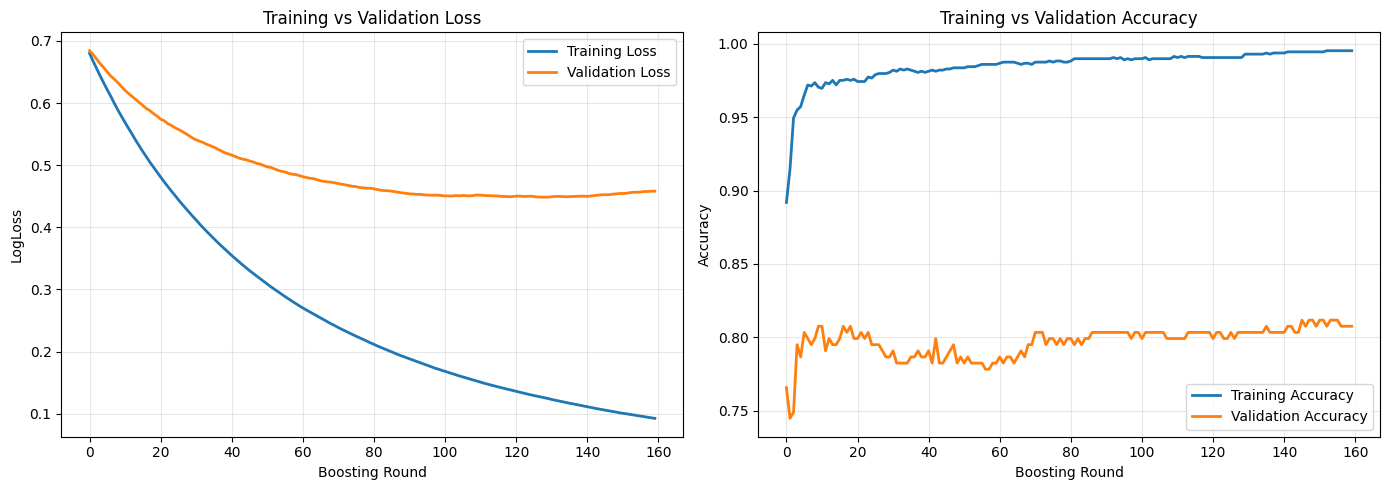

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Get evaluation results
results = xgb_model.evals_result()

# ==========================================
# Loss
# ==========================================

train_loss = results['validation_0']['logloss']
val_loss   = results['validation_1']['logloss']

epochs = range(len(train_loss))

# ==========================================
# Accuracy
# ==========================================

train_acc = []
val_acc   = []

for i in range(len(train_loss)):# we manually compute accuracy history

    # Training predictions
    y_train_pred = xgb_model.predict(
        X_train_xgb,
        iteration_range=(0, i + 1)#predicts using the partially trained model at that stage.
    )

    train_acc.append(
        accuracy_score(y_train, y_train_pred)
    )

    # Validation predictions
    y_val_pred = xgb_model.predict(
        X_valid_xgb,
        iteration_range=(0, i + 1)
    )

    val_acc.append(
        accuracy_score(y_valid, y_val_pred)
    )

# ==========================================
# Plot
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ----------------------
# Loss Plot
# ----------------------

axes[0].plot(
    epochs,
    train_loss,
    label='Training Loss',
    linewidth=2
)

axes[0].plot(
    epochs,
    val_loss,
    label='Validation Loss',
    linewidth=2
)

axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('LogLoss')
axes[0].set_title('Training vs Validation Loss')

axes[0].legend()

axes[0].grid(True, alpha=0.3)

# ----------------------
# Accuracy Plot
# ----------------------

axes[1].plot(
    epochs,
    train_acc,
    label='Training Accuracy',
    linewidth=2
)

axes[1].plot(
    epochs,
    val_acc,
    label='Validation Accuracy',
    linewidth=2
)

axes[1].set_xlabel('Boosting Round')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy')

axes[1].legend()

axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

hyperparamter tuning

In [ ]:
# Install first if needed:
# pip install scikit-optimize

import pandas as pd

from xgboost import XGBClassifier

from skopt import BayesSearchCV
from skopt.space import Real, Integer


# Base model
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)


# Search space
search_spaces = {

    'max_depth': Integer(3, 8),

    'learning_rate': Real(0.005, 0.1, prior='log-uniform'),

    'n_estimators': Integer(100, 1000),

    'subsample': Real(0.6, 1.0),

    'colsample_bytree': Real(0.6, 1.0),

    'min_child_weight': Integer(1, 10),

    'reg_alpha': Real(0.0, 5.0),

    'reg_lambda': Real(1.0, 10.0)
}


# Bayesian Optimization
bayes_search = BayesSearchCV(

    estimator=xgb_base,

    search_spaces=search_spaces,

    n_iter=30,

    scoring='accuracy',

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=-1
)


# Train
bayes_search.fit(X_train_xgb, y_train)


# Best result
print("\nBest Parameters:")
print(bayes_search.best_params_)

print("\nBest Accuracy:")
print(f"{bayes_search.best_score_:.4f}")


# Convert all results to DataFrame
results = pd.DataFrame(bayes_search.cv_results_)


# Sort by best score
top_10 = results.sort_values(by='rank_test_score').head(10)


# Print top 10 results
print("\nTop 10 Results:\n")

for i, row in top_10.iterrows():

    print(f"Rank #{row['rank_test_score']}")

    print(f"Mean Accuracy: {row['mean_test_score']:.4f}")

    print("Parameters:")

    print(row['params'])

    print("-" * 60)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

In [ ]:
# Install if needed
# pip install scikit-optimize xgboost

import pandas as pd
import numpy as np

from xgboost import XGBClassifier

from skopt import Optimizer
from skopt.space import Real, Integer

from sklearn.metrics import accuracy_score


# =========================
# SEARCH SPACE
# =========================

space = [

    Integer(3, 8, name='max_depth'),

    Real(0.005, 0.1, prior='log-uniform', name='learning_rate'),

    Integer(100, 1000, name='n_estimators'),

    Real(0.6, 1.0, name='subsample'),

    Real(0.6, 1.0, name='colsample_bytree'),

    Integer(1, 10, name='min_child_weight'),

    Real(0.0, 5.0, name='reg_alpha'),

    Real(1.0, 10.0, name='reg_lambda')
]


# =========================
# BAYESIAN OPTIMIZER
# =========================

opt = Optimizer(
    dimensions=space,
    random_state=42
)


# =========================
# STORE RESULTS
# =========================

best_acc = 0
best_params = None

all_results = []


# =========================
# BAYESIAN OPTIMIZATION LOOP
# =========================

for i in range(30):

    print(f"\n========== Iteration {i+1} ==========")

    # Ask optimizer for next hyperparameters
    params = opt.ask()

    # Create model using suggested parameters
    model = XGBClassifier(

        objective='binary:logistic',

        eval_metric='logloss',

        random_state=42,

        max_depth=params[0],

        learning_rate=params[1],

        n_estimators=params[2],

        subsample=params[3],

        colsample_bytree=params[4],

        min_child_weight=params[5],

        reg_alpha=params[6],

        reg_lambda=params[7]
    )

    # =========================
    # TRAIN ONLY ON TRAINING SET
    # =========================

    model.fit(X_train_seq, y_train)

    # =========================
    # VALIDATION SET EVALUATION
    # =========================

    preds = model.predict(X_valid_seq)

    acc = accuracy_score(y_valid, preds)

    # Tell optimizer the result
    # negative because optimizer minimizes
    opt.tell(params, -acc)

    # =========================
    # PRINT CURRENT RESULT
    # =========================

    print(f"Validation Accuracy: {acc:.4f}")

    print("Parameters:")

    print(f"max_depth: {params[0]}")

    print(f"learning_rate: {params[1]:.5f}")

    print(f"n_estimators: {params[2]}")

    print(f"subsample: {params[3]:.4f}")

    print(f"colsample_bytree: {params[4]:.4f}")

    print(f"min_child_weight: {params[5]}")

    print(f"reg_alpha: {params[6]:.4f}")

    print(f"reg_lambda: {params[7]:.4f}")

    # =========================
    # SAVE RESULTS
    # =========================

    all_results.append({

        'iteration': i + 1,

        'max_depth': params[0],

        'learning_rate': params[1],

        'n_estimators': params[2],

        'subsample': params[3],

        'colsample_bytree': params[4],

        'min_child_weight': params[5],

        'reg_alpha': params[6],

        'reg_lambda': params[7],

        'val_accuracy': acc
    })

    # =========================
    # UPDATE BEST RESULT
    # =========================

    if acc > best_acc:

        best_acc = acc

        best_params = params


# =========================
# BEST RESULT
# =========================

print("\n" + "="*60)

print("BEST VALIDATION RESULT")

print("="*60)

print(f"Best Validation Accuracy: {best_acc:.4f}")

print("\nBest Parameters:")

print(f"max_depth: {best_params[0]}")

print(f"learning_rate: {best_params[1]:.5f}")

print(f"n_estimators: {best_params[2]}")

print(f"subsample: {best_params[3]:.4f}")

print(f"colsample_bytree: {best_params[4]:.4f}")

print(f"min_child_weight: {best_params[5]}")

print(f"reg_alpha: {best_params[6]:.4f}")

print(f"reg_lambda: {best_params[7]:.4f}")


# =========================
# TOP 10 RESULTS
# =========================

results_df = pd.DataFrame(all_results)

top_10 = results_df.sort_values(
    by='val_accuracy',
    ascending=False
).head(10)

print("\n" + "="*60)

print("TOP 10 RESULTS")

print("="*60)

for rank, (_, row) in enumerate(top_10.iterrows(), start=1):

    print(f"\nRank #{rank}")

    print(f"Validation Accuracy: {row['val_accuracy']:.4f}")

    print(f"max_depth: {row['max_depth']}")

    print(f"learning_rate: {row['learning_rate']:.5f}")

    print(f"n_estimators: {row['n_estimators']}")

    print(f"subsample: {row['subsample']:.4f}")

    print(f"colsample_bytree: {row['colsample_bytree']:.4f}")

    print(f"min_child_weight: {row['min_child_weight']}")

    print(f"reg_alpha: {row['reg_alpha']:.4f}")

    print(f"reg_lambda: {row['reg_lambda']:.4f}")

    print("-" * 50)


# =========================
# SAVE RESULTS TO CSV
# =========================

results_df.to_csv(
    'xgboost_bayesian_optimization_results.csv',
    index=False
)

print("\nResults saved successfully!")


========== Iteration 1 ==========
Validation Accuracy: 0.7586
Parameters:
max_depth: 7
learning_rate: 0.00866
n_estimators: 802
subsample: 0.8387
colsample_bytree: 0.7783
min_child_weight: 2
reg_alpha: 2.2962
reg_lambda: 4.0034

========== Iteration 2 ==========
Validation Accuracy: 0.7724
Parameters:
max_depth: 4
learning_rate: 0.03514
n_estimators: 151
subsample: 0.8888
colsample_bytree: 0.9754
min_child_weight: 1
reg_alpha: 4.9611
reg_lambda: 6.5573

========== Iteration 3 ==========
Validation Accuracy: 0.7655
Parameters:
max_depth: 6
learning_rate: 0.00511
n_estimators: 121
subsample: 0.8099
colsample_bytree: 0.7599
min_child_weight: 1
reg_alpha: 4.8688
reg_lambda: 3.0949

========== Iteration 4 ==========
Validation Accuracy: 0.7517
Parameters:
max_depth: 3
learning_rate: 0.03188
n_estimators: 444
subsample: 0.9933
colsample_bytree: 0.7867
min_child_weight: 9
reg_alpha: 3.4015
reg_lambda: 5.0545

========== Iteration 5 ==========
Validation Accuracy: 0.7448
Parameters:
max_depth

In [ ]:
print(random_search.best_params_)
print(random_search.best_score_)#on the validation

{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.02, 'colsample_bytree': 1.0}
0.952740669259174


In [ ]:

best_xgb = random_search.best_estimator_

y_pred = best_xgb.predict(X_test_xgb)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.62      0.66       316
           1       0.55      0.66      0.60       221

    accuracy                           0.63       537
   macro avg       0.63      0.64      0.63       537
weighted avg       0.65      0.63      0.64       537



In [ ]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# Video-level XGBoost Evaluation
# =========================================================

def video_level_xgb(
    model,
    X_data,
    y_labels,
    video_ids,
    threshold=0.5
):
    """
    Soft Voting for XGBoost
    """

    # -----------------------------------------
    # Predict probabilities
    # -----------------------------------------

    probas = model.predict_proba(X_data)[:, 1]

    df = pd.DataFrame({
        'video_id':   video_ids,
        'true_label': y_labels,
        'proba':      probas
    })

    results = []

    # =====================================================
    # Group by video
    # =====================================================

    for video_id, g in df.groupby('video_id'):

        # -----------------------------------------
        # Video-level prediction
        # -----------------------------------------

        mean_proba = g['proba'].mean()

        final_pred = int(mean_proba >= threshold)

        true_label = int(g['true_label'].iloc[0])

        results.append({

            'video_id': video_id,

            'subject_id': video_id.split('_')[0],

            'true_label': true_label,

            'predicted_label': final_pred,

            'mean_proba': round(mean_proba, 3),

            'n_sequences': len(g)
        })

        # =====================================================
        # Segment-level metrics
        # =====================================================

        segment_preds = (g['proba'] >= threshold).astype(int)

        bsa, bsre = compute_bsa_bsre(
            g['true_label'],
            segment_preds,
            g['proba']
        )

        print("\n" + "=" * 60)
        print(f"Video ID: {video_id}")
        print("=" * 60)

        print(f"BSA:  {bsa:.4f}")
        print(f"BSRE: {bsre:.6f}")

        # =====================================================
        # Print all segments
        # =====================================================

        for segment_num, (_, row) in enumerate(
            g.iterrows(),
            start=1
        ):

            segment_pred = int(row['proba'] >= threshold)

            segment_class = (
                'Drowsy'
                if segment_pred == 1
                else 'Alert'
            )

            print(
                f"Segment {segment_num:<3} | "
                f"Probability: {row['proba']:.4f} | "
                f"Predicted Class: {segment_class}"
            )

    return pd.DataFrame(results)


# =========================================================
# Threshold Search
# =========================================================

print("\nVideo-level evaluation (Soft Voting) - XGBoost")
print("=" * 75)

print(
    f"\n{'Threshold':<12}"
    f"{'Accuracy':<12}"
    f"{'Precision':<12}"
    f"{'Recall':<12}"
    f"{'F1':<10}"
)

print("-" * 58)

best_t = 0.5
best_f1 = 0

for t in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]:

    df = video_level_xgb(
        best_xgb,
        X_test_xgb,
        y_test,
        test_video_ids,
        threshold=t
    )

    a = accuracy_score(
        df['true_label'],
        df['predicted_label']
    )

    p = precision_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    r = recall_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    f = f1_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    print(
        f"{t:<12}"
        f"{a:<12.4f}"
        f"{p:<12.4f}"
        f"{r:<12.4f}"
        f"{f:<10.4f}"
    )

    if f > best_f1:
        best_f1 = f
        best_t = t

print(f"\nBest Threshold: {best_t}")

# =========================================================
# Final Video-Level Evaluation
# =========================================================

final_df = video_level_xgb(
    best_xgb,
    X_test_xgb,
    y_test,
    test_video_ids,
    threshold=best_t
)

# =========================================================
# Class Names
# =========================================================

final_df['true_class'] = final_df['true_label'].map({
    0: 'Alert',
    1: 'Drowsy'
})

final_df['predicted_class'] = final_df['predicted_label'].map({
    0: 'Alert',
    1: 'Drowsy'
})

final_df['Status'] = np.where(
    final_df['true_label'] == final_df['predicted_label'],
    'true',
    'false'
)

# =========================================================
# Video Details
# =========================================================

print("\nVideo Details")
print("=" * 75)

print(

    final_df[
        [
            'subject_id',
            'true_class',
            'predicted_class',
            'mean_proba',
            'n_sequences',
            'Status'
        ]
    ].to_string(index=False)

)

# =========================================================
# Final Metrics
# =========================================================

final_acc = accuracy_score(
    final_df['true_label'],
    final_df['predicted_label']
)

final_p = precision_score(
    final_df['true_label'],
    final_df['predicted_label'],
    zero_division=0
)

final_r = recall_score(
    final_df['true_label'],
    final_df['predicted_label'],
    zero_division=0
)

final_f1 = f1_score(
    final_df['true_label'],
    final_df['predicted_label'],
    zero_division=0
)

# =========================================================
# VRE / VA
# =========================================================

vre, va = compute_vre(
    final_df['true_label'],
    final_df['predicted_label'],
    final_df['mean_proba']
)

# =========================================================
# Final Results
# =========================================================

print("\nFinal result at the video level:")
print("=" * 50)

print(f"Accuracy:  {final_acc*100:.1f}%")
print(f"Precision: {final_p:.4f}")
print(f"Recall:    {final_r:.4f}")
print(f"F1 Score:  {final_f1:.4f}")

print(f"VA  (Video Accuracy):      {va:.4f}")
print(f"VRE (Video Ranking Error): {vre:.6f}")

Streaming output truncated to the last 5000 lines.
Segment 26  | Probability: 0.9720 | Predicted Class: Drowsy

Video ID: D024_20260513_212814_frames
BSA:  1.0000
BSRE: 0.000000
Segment 1   | Probability: 0.9761 | Predicted Class: Drowsy
Segment 2   | Probability: 0.9354 | Predicted Class: Drowsy
Segment 3   | Probability: 0.9128 | Predicted Class: Drowsy
Segment 4   | Probability: 0.8395 | Predicted Class: Drowsy
Segment 5   | Probability: 0.8561 | Predicted Class: Drowsy
Segment 6   | Probability: 0.7607 | Predicted Class: Drowsy
Segment 7   | Probability: 0.8042 | Predicted Class: Drowsy
Segment 8   | Probability: 0.4830 | Predicted Class: Drowsy
Segment 9   | Probability: 0.3832 | Predicted Class: Drowsy
Segment 10  | Probability: 0.5934 | Predicted Class: Drowsy
Segment 11  | Probability: 0.5215 | Predicted Class: Drowsy
Segment 12  | Probability: 0.6125 | Predicted Class: Drowsy
Segment 13  | Probability: 0.5358 | Predicted Class: Drowsy
Segment 14  | Probability: 0.6278 | Predic

In [10]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

BOUNDARY = 0.5

def compute_bsa(y_true, y_pred, boundary=BOUNDARY):

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)






    bsa = accuracy_score(y_true, y_pred)

    return bsa



def compute_va(y_true, y_pred, boundary=0.5):

    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)




    va = accuracy_score(y_true, y_pred)
    return  va

the old verison

🎬 تقييم على مستوى الفيديو (مع Majority Voting)...

🎯 دقة التصنيف على مستوى الفيديو: 0.8000 (80.0%)
   عدد الفيديوهات المصنّفة صح: 8 من أصل 10

📋 تقرير التصنيف على مستوى الفيديو:
              precision    recall  f1-score   support

       Alert     0.7143    1.0000    0.8333         5
      Drowsy     1.0000    0.6000    0.7500         5

    accuracy                         0.8000        10
   macro avg     0.8571    0.8000    0.7917        10
weighted avg     0.8571    0.8000    0.7917        10

📊 تفاصيل كل فيديو في بيانات الاختبار:
subject_id true_class predicted_class  drowsy_probability  n_windows correct
      A023      Alert           Alert               0.271        474       ✅
      A025      Alert           Alert               0.167        351       ✅
      A027      Alert           Alert               0.076        248       ✅
      A028      Alert           Alert               0.252        275       ✅
      A029      Alert           Alert               0.169        443    

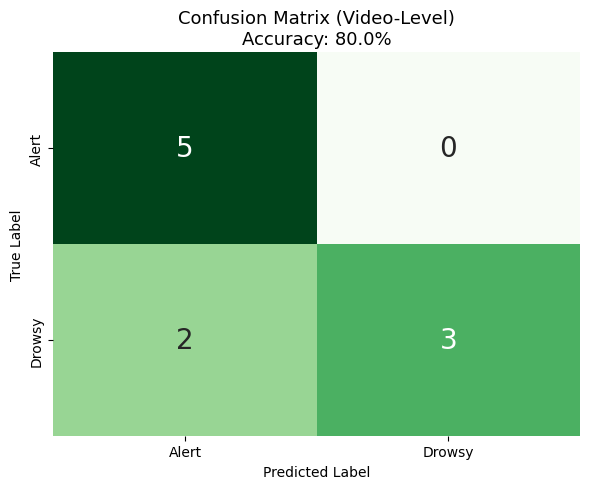

In [ ]:
def video_level_predict(model, windows_df, feature_cols):
    """
    لكل فيديو:
    1. نتنبأ بكل نافذة على حدة
    2. نعمل majority voting على النوافذ
    3. نطلع التنبؤ النهائي للفيديو
    """
    results = []

    for video_id, g in windows_df.groupby('video_id'):
        X_vid = g[feature_cols].values
        X_vid = np.nan_to_num(X_vid, nan=0.0, posinf=0.0, neginf=0.0)

        preds = model.predict(X_vid)
        probas = model.predict_proba(X_vid)[:, 1]

        # Majority voting
        final_pred = int(np.bincount(preds).argmax())

        mean_drowsy_proba = probas.mean()

        true_label = int(g['label'].iloc[0])
        subject_id = g['subject_id'].iloc[0]

        results.append({
            'video_id':           video_id,
            'subject_id':         subject_id,
            'true_label':         true_label,
            'true_class':         'Alert' if true_label == 0 else 'Drowsy',
            'predicted_label':    final_pred,
            'predicted_class':    'Alert' if final_pred == 0 else 'Drowsy',
            'drowsy_probability': round(mean_drowsy_proba, 3),
            'n_windows':          len(g),
            'correct':            '✅' if final_pred == true_label else '❌'
        })

    return pd.DataFrame(results)

print(" تقييم على مستوى الفيديو (مع Majority Voting)...")
video_results = video_level_predict(model, test_windows, feature_cols)

video_acc = (video_results['true_label'] == video_results['predicted_label']).mean()

print(f"\n{'=' * 55}")
print(f" دقة التصنيف على مستوى الفيديو: {video_acc:.4f} ({video_acc*100:.1f}%)")
print(f"   عدد الفيديوهات المصنّفة صح: "
      f"{(video_results['true_label'] == video_results['predicted_label']).sum()} "
      f"من أصل {len(video_results)}")
print(f"{'=' * 55}\n")

print(" تقرير التصنيف على مستوى الفيديو:")
print(classification_report(
    video_results['true_label'],
    video_results['predicted_label'],
    target_names=['Alert', 'Drowsy'],
    digits=4
))

print(" تفاصيل كل فيديو في بيانات الاختبار:")
display_cols = ['subject_id', 'true_class', 'predicted_class',
                'drowsy_probability', 'n_windows', 'correct']
print(video_results[display_cols].to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
cm_video = confusion_matrix(video_results['true_label'],
                             video_results['predicted_label'])
sns.heatmap(cm_video, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Alert', 'Drowsy'],
            yticklabels=['Alert', 'Drowsy'],
            cbar=False, annot_kws={'size': 20})
ax.set_title(f'Confusion Matrix (Video-Level)\nAccuracy: {video_acc*100:.1f}%',
             fontsize=13)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

best thershold


Threshold experiments at video level:
Threshold   Accuracy    F1(Drowsy)    Precision   Recall    
0.2         0.3750      0.5455        0.3750      1.0000    
0.25        0.3750      0.5455        0.3750      1.0000    
0.3         0.3750      0.5455        0.3750      1.0000    
0.35        0.3750      0.5455        0.3750      1.0000    
0.4         0.5000      0.6000        0.4286      1.0000    
0.45        0.5000      0.6000        0.4286      1.0000    
0.5         0.5000      0.5000        0.4000      0.6667     current
0.55        0.5000      0.5000        0.4000      0.6667    
0.6         0.5000      0.5000        0.4000      0.6667    


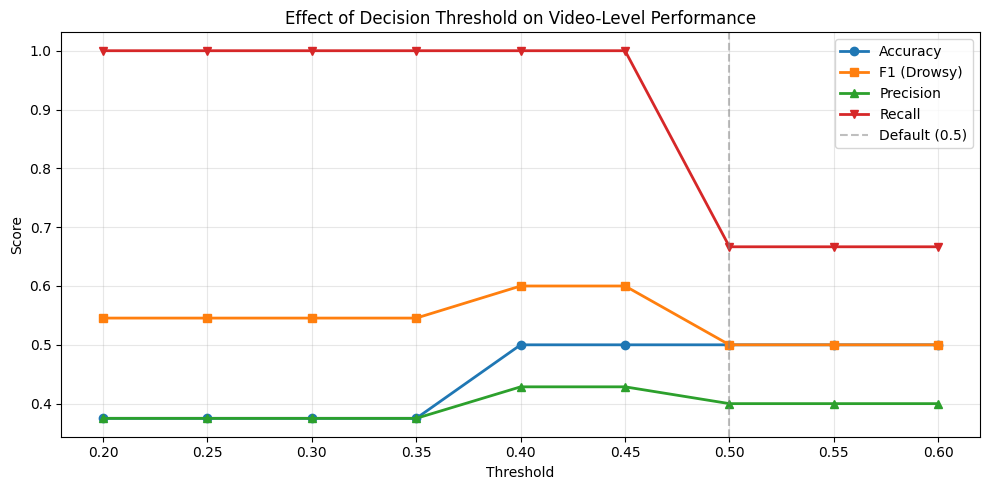


Best threshold: 0.4
Accuracy: 0.5000 (50.0%)
F1 Score: 0.6000


In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_at_threshold(
    model,
    X_test_seq,
    y_test,
    test_video_ids,
    threshold
):

    # Flatten sequences for XGBoost
    X_flat = X_test_seq.reshape(X_test_seq.shape[0], -1)

    X_flat = np.nan_to_num(
        X_flat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # Probabilities
    probas = model.predict_proba(X_flat)[:, 1]

    # Sequence predictions
    preds = (probas >= threshold).astype(int)

    # Store sequence-level results
    seq_df = pd.DataFrame({
        'video_id': test_video_ids,
        'true_label': y_test,
        'pred': preds,
        'proba': probas
    })

    # Video-level aggregation
    results = []

    for video_id, g in seq_df.groupby('video_id'):

        final_pred = int(np.bincount(g['pred']).argmax())

        true_label = int(g['true_label'].iloc[0])

        results.append({
            'video_id': video_id,
            'true_label': true_label,
            'predicted_label': final_pred,
            'mean_proba': round(g['proba'].mean(), 3)
        })

    df = pd.DataFrame(results)

    # Metrics
    acc = (df['true_label'] == df['predicted_label']).mean()

    f1 = f1_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    prec = precision_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    rec = recall_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    return df, acc, f1, prec, rec


print("Threshold experiments at video level:")
print("=" * 72)

print(
    f"{'Threshold':<12}"
    f"{'Accuracy':<12}"
    f"{'F1(Drowsy)':<14}"
    f"{'Precision':<12}"
    f"{'Recall':<10}"
)

print("=" * 72)

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

results_summary = []

for t in thresholds:

    _, acc, f1, prec, rec = evaluate_at_threshold(
        model=best_xgb,
        X_test_seq=X_test_seq,
        y_test=y_test,
        test_video_ids=test_video_ids,
        threshold=t
    )

    marker = " current" if t == 0.5 else ""

    print(
        f"{t:<12}"
        f"{acc:<12.4f}"
        f"{f1:<14.4f}"
        f"{prec:<12.4f}"
        f"{rec:<10.4f}"
        f"{marker}"
    )

    results_summary.append({
        'threshold': t,
        'acc': acc,
        'f1': f1,
        'precision': prec,
        'recall': rec
    })


summary_df = pd.DataFrame(results_summary)

# Plot
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(summary_df['threshold'], summary_df['acc'],
        'o-', label='Accuracy', linewidth=2)

ax.plot(summary_df['threshold'], summary_df['f1'],
        's-', label='F1 (Drowsy)', linewidth=2)

ax.plot(summary_df['threshold'], summary_df['precision'],
        '^-', label='Precision', linewidth=2)

ax.plot(summary_df['threshold'], summary_df['recall'],
        'v-', label='Recall', linewidth=2)

ax.axvline(
    x=0.5,
    color='gray',
    linestyle='--',
    alpha=0.5,
    label='Default (0.5)'
)

ax.set_xlabel('Threshold')
ax.set_ylabel('Score')

ax.set_title(
    'Effect of Decision Threshold on Video-Level Performance'
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Best threshold
best_idx = summary_df['f1'].idxmax()

best_t = summary_df.loc[best_idx, 'threshold']
best_acc = summary_df.loc[best_idx, 'acc']
best_f1 = summary_df.loc[best_idx, 'f1']

print("\nBest threshold:", best_t)

print(f"Accuracy: {best_acc:.4f} ({best_acc*100:.1f}%)")

print(f"F1 Score: {best_f1:.4f}")

In [ ]:
def soft_voting_sequence_evaluation(
    model,
    X_seq,
    y_true,
    video_ids,
    subject_ids=None,
    threshold=0.5
):
    """
    Sequence-Level Soft Voting

    For each video:
    - Predict probabilities for all sequences
    - Compute mean probability
    - Apply threshold once per video
    """

    # =====================================
    # Flatten sequences for XGBoost
    # =====================================

    X_flat = X_seq.reshape(X_seq.shape[0], -1)

    X_flat = np.nan_to_num(
        X_flat,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # =====================================
    # Predict probabilities
    # =====================================

    probas = model.predict_proba(X_flat)[:, 1]

    # =====================================
    # Build temporary dataframe
    # =====================================

    temp_df = pd.DataFrame({

        'video_id': video_ids,

        'true_label': y_true,

        'proba': probas

    })

    if subject_ids is not None:

        temp_df['subject_id'] = subject_ids

    # =====================================
    # Soft Voting Per Video
    # =====================================

    results = []

    for video_id, g in temp_df.groupby('video_id'):

        mean_proba = g['proba'].mean()

        final_pred = 1 if mean_proba >= threshold else 0

        true_label = int(g['true_label'].iloc[0])

        result = {

            'video_id': video_id,

            'true_label': true_label,

            'predicted_label': final_pred,

            'mean_proba': round(mean_proba, 4),

            'max_proba': round(g['proba'].max(), 4),

            'median_proba': round(g['proba'].median(), 4),

            'std_proba': round(g['proba'].std(), 4)

        }

        if subject_ids is not None:

            result['subject_id'] = g['subject_id'].iloc[0]

        results.append(result)

    # =====================================
    # Final Results DataFrame
    # =====================================

    df = pd.DataFrame(results)

    # =====================================
    # Metrics
    # =====================================

    acc = accuracy_score(
        df['true_label'],
        df['predicted_label']
    )

    f1 = f1_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    prec = precision_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    rec = recall_score(
        df['true_label'],
        df['predicted_label'],
        zero_division=0
    )

    return df, acc, f1, prec, rec

In [ ]:
def soft_voting_evaluation(model, test_windows, feature_cols, threshold=0.5):
    """
    Soft Voting: نأخذ متوسط احتمالات كل النوافذ،
    ثم نقارنها بـ threshold واحد للفيديو ككل.
    """
    results = []
    for video_id, g in test_windows.groupby('video_id'):
        X_vid = g[feature_cols].values
        X_vid = np.nan_to_num(X_vid, nan=0.0, posinf=0.0, neginf=0.0)
        probas = model.predict_proba(X_vid)[:, 1]
        mean_proba = probas.mean()
        final_pred = 1 if mean_proba >= threshold else 0
        true_label = int(g['label'].iloc[0])
        results.append({
            'video_id':         video_id,
            'subject_id':       g['subject_id'].iloc[0],
            'true_label':       true_label,
            'predicted_label':  final_pred,
            'mean_proba':       round(mean_proba, 3),
            'max_proba':        round(probas.max(), 3),
            'median_proba':     round(np.median(probas), 3),
            'std_proba':        round(probas.std(), 3),
        })
    df = pd.DataFrame(results)
    acc = (df['true_label'] == df['predicted_label']).mean()
    f1 = f1_score(df['true_label'], df['predicted_label'], zero_division=0)
    prec = precision_score(df['true_label'], df['predicted_label'], zero_division=0)
    rec = recall_score(df['true_label'], df['predicted_label'], zero_division=0)
    return df, acc, f1, prec, rec


# ==========================================
# نجرّب thresholds مختلفة مع Soft Voting
# ==========================================
print("🔬 Soft Voting: تجربة thresholds مختلفة:")
print("=" * 72)
print(f"{'Threshold':<12}{'Accuracy':<12}{'F1(Drowsy)':<14}{'Precision':<12}{'Recall':<10}")
print("=" * 72)

thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
soft_results = []

for t in thresholds:
    _, acc, f1, prec, rec = soft_voting_evaluation(model, test_windows, feature_cols, t)
    print(f"{t:<12}{acc:<12.4f}{f1:<14.4f}{prec:<12.4f}{rec:<10.4f}")
    soft_results.append({'threshold': t, 'acc': acc, 'f1': f1,
                         'precision': prec, 'recall': rec})

# اختيار الأفضل
soft_df = pd.DataFrame(soft_results)
best_idx = soft_df['f1'].idxmax()
best_t = soft_df.loc[best_idx, 'threshold']
best_acc = soft_df.loc[best_idx, 'acc']
best_f1 = soft_df.loc[best_idx, 'f1']

print(f"\n🏆 أفضل threshold مع Soft Voting: {best_t}")
print(f"   Accuracy: {best_acc:.4f} ({best_acc*100:.1f}%)")
print(f"   F1: {best_f1:.4f}")

# ==========================================
# عرض تفاصيل كل فيديو مع أفضل threshold
# ==========================================
print(f"\n📊 تفاصيل كل فيديو مع threshold = {best_t}:\n")
best_results_df, _, _, _, _ = soft_voting_evaluation(
    model, test_windows, feature_cols, best_t)

# 🔧 إضافة الأعمدة المطلوبة (هذا اللي كان مفقود!)
best_results_df['true_class']      = best_results_df['true_label'].map({0: 'Alert', 1: 'Drowsy'})
best_results_df['predicted_class'] = best_results_df['predicted_label'].map({0: 'Alert', 1: 'Drowsy'})
best_results_df['correct']         = np.where(
    best_results_df['true_label'] == best_results_df['predicted_label'], '✅', '❌')

# عرض الجدول
display_cols = ['subject_id', 'true_class', 'predicted_class',
                'mean_proba', 'max_proba', 'median_proba', 'correct']
print(best_results_df[display_cols].to_string(index=False))

🔬 Soft Voting: تجربة thresholds مختلفة:
Threshold   Accuracy    F1(Drowsy)    Precision   Recall    
0.25        0.8000      0.8333        0.7143      1.0000    
0.3         1.0000      1.0000        1.0000      1.0000    
0.35        0.9000      0.8889        1.0000      0.8000    
0.4         0.8000      0.7500        1.0000      0.6000    
0.45        0.8000      0.7500        1.0000      0.6000    
0.5         0.8000      0.7500        1.0000      0.6000    
0.55        0.8000      0.7500        1.0000      0.6000    

🏆 أفضل threshold مع Soft Voting: 0.3
   Accuracy: 1.0000 (100.0%)
   F1: 1.0000

📊 تفاصيل كل فيديو مع threshold = 0.3:

subject_id true_class predicted_class  mean_proba  max_proba  median_proba correct
      A023      Alert           Alert       0.271      0.998         0.100       ✅
      A025      Alert           Alert       0.167      0.875         0.073       ✅
      A027      Alert           Alert       0.076      0.813         0.027       ✅
      A028      Ale

🎯 النتيجة النهائية مع Soft Voting (threshold=0.25):
   Accuracy:  0.8000 (80.0%)
   F1:        0.8333
   Precision: 0.7143
   Recall:    1.0000

📊 تفاصيل كل فيديو:

subject_id true_class predicted_class  mean_proba  max_proba  median_proba correct
      A023      Alert          Drowsy       0.271      0.998         0.100       ❌
      A025      Alert           Alert       0.167      0.875         0.073       ✅
      A027      Alert           Alert       0.076      0.813         0.027       ✅
      A028      Alert          Drowsy       0.252      0.975         0.113       ❌
      A029      Alert           Alert       0.169      0.981         0.080       ✅
      D023     Drowsy          Drowsy       0.852      1.000         0.937       ✅
      D024     Drowsy          Drowsy       0.593      0.998         0.735       ✅
      D025     Drowsy          Drowsy       0.303      0.981         0.211       ✅
      D028     Drowsy          Drowsy       0.629      0.999         0.832       ✅
     

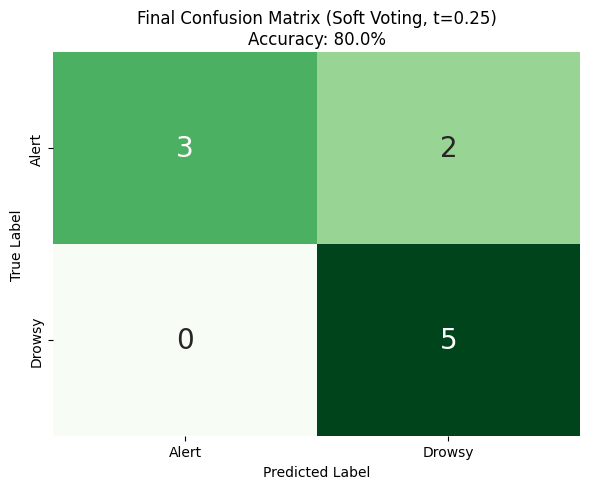

In [ ]:
BEST_THRESHOLD = 0.25

best_results_df, acc, f1, prec, rec = soft_voting_evaluation(
    model, test_windows, feature_cols, BEST_THRESHOLD)

best_results_df['true_class']      = best_results_df['true_label'].map({0: 'Alert', 1: 'Drowsy'})
best_results_df['predicted_class'] = best_results_df['predicted_label'].map({0: 'Alert', 1: 'Drowsy'})
best_results_df['correct']         = np.where(
    best_results_df['true_label'] == best_results_df['predicted_label'], '✅', '❌')

print(f" النتيجة النهائية مع Soft Voting (threshold={BEST_THRESHOLD}):")
print(f"   Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"   F1:        {f1:.4f}")
print(f"   Precision: {prec:.4f}")
print(f"   Recall:    {rec:.4f}")
print()

print(" تفاصيل كل فيديو:\n")
display_cols = ['subject_id', 'true_class', 'predicted_class',
                'mean_proba', 'max_proba', 'median_proba', 'correct']
print(best_results_df[display_cols].to_string(index=False))

print("\n تقرير التصنيف الكامل:")
print(classification_report(
    best_results_df['true_label'],
    best_results_df['predicted_label'],
    target_names=['Alert', 'Drowsy'],
    digits=4
))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(best_results_df['true_label'], best_results_df['predicted_label'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Alert', 'Drowsy'],
            yticklabels=['Alert', 'Drowsy'],
            cbar=False, annot_kws={'size': 20})
ax.set_title(f'Final Confusion Matrix (Soft Voting, t={BEST_THRESHOLD})\nAccuracy: {acc*100:.1f}%',
             fontsize=12)
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
plt.tight_layout()
plt.show()

**test of overfit**

In [ ]:
#   Overfitting 1:  Train vs Test

from sklearn.metrics import accuracy_score, f1_score

X_train_clean = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test_clean  = np.nan_to_num(X_test,  nan=0.0, posinf=0.0, neginf=0.0)

y_train_pred = model.predict(X_train_clean)
y_test_pred  = model.predict(X_test_clean)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_test_pred)
train_f1  = f1_score(y_train, y_train_pred)
test_f1   = f1_score(y_test, y_test_pred)

gap_acc = train_acc - test_acc
gap_f1  = train_f1 - test_f1

print("=" * 60)
print(" اختبار Overfitting: مقارنة Train vs Test")
print("=" * 60)
print(f"\n{'المقياس':<15}{'Training':<15}{'Testing':<15}{'الفرق':<10}")
print("-" * 55)
print(f"{'Accuracy':<15}{train_acc*100:<15.2f}{test_acc*100:<15.2f}{gap_acc*100:<10.2f}")
print(f"{'F1 Score':<15}{train_f1:<15.4f}{test_f1:<15.4f}{gap_f1:<10.4f}")

print("\n التقييم:")
if gap_acc < 0.10:
    print("    ممتاز! الفرق صغير (أقل من 10%) — النموذج ما overfitted")
elif gap_acc < 0.20:
    print("    مقبول. فيه overfitting بسيط (10-20%)")
else:
    print("   تحذير! فرق كبير جداً — النموذج overfitted")

print(f"\n قاعدة عامة:")
print(f"   - فرق < 5%  → ممتاز")
print(f"   - فرق 5-15% → طبيعي (معظم النماذج)")
print(f"   - فرق > 20% → overfitting")

🔍 اختبار Overfitting: مقارنة Train vs Test

المقياس        Training       Testing        الفرق     
-------------------------------------------------------
Accuracy       99.91          73.73          26.17     
F1 Score       0.9983         0.5947         0.4035    

💡 التقييم:
   ❌ تحذير! فرق كبير جداً — النموذج overfitted

📊 قاعدة عامة:
   - فرق < 5%  → ممتاز
   - فرق 5-15% → طبيعي (معظم النماذج)
   - فرق > 20% → overfitting
